# Alzheimer's Severety Among Different Demographic Groups

> Author: Laiba Siddique
> Institution: The George Washington University
> Course: Introduction to Health Data Science PUBH 1142
> May 4, 2026

## Python Setup

Importing all required packages for this notebook. 

In [75]:
# Import packages for numerical computations, statistics, polotting, and data wrangling
import numpy as np # Numerical Calculations 
import pandas as pd # Manipulating data
import matplotlib.pyplot as plt # Plotting
import seaborn as sns # Advanced Plotting
from scipy import stats # Statistical functions

Setting up the notebook to display high resolution figures. 

In [18]:
%config InlineBackend.figure_format = 'retina'  # High-resolution plots for Jupyter Notebooks

This notebook was developed in a VSCode dark theme. So, set the seaborn theme to dark. Also set the seaborn color palatte to be colorblind friendly. 

In [63]:
sns.set_theme(style='dark')
sns.set_style('dark')
sns.set_palette('colorblind')
# plt.style.use('darkbackground')

## Introduction

Alzheimer's disease (AD) is a progressive neurodegenerative disorder and the most prevalent cause of dementia, accounting for at least two-thirds of dementia cases in individuals aged $65$ and older <sup>[$1$](#link_1)</sup>. An estimated $6.9$ million Americans age $65$ and older are currently living with Alzheimer's dementia, a figure that could grow to $13.8$ million by $2060$ barring the development of medical breakthroughs <sup>[$2$](#link_2)</sup>. The disease imposes a staggering societal burden: between $2000$ and $2021$, reported deaths from AD increased more than $140\%$, and over $11$ million family members and other unpaid caregivers provided an estimated $18.4$ billion hours of care to people with Alzheimer's or other dementias in $2023$, with the value of that unpaid care estimated at $\$346.6$ billion <sup>[$2$](#link_2)</sup>. Clinically, AD is characterized by a continuum of cognitive decline, beginning with preclinical changes and advancing through mild cognitive impairment (MCI) to increasingly severe stages of dementia. As a patient progresses through mild, moderate, and severe stages of AD, greater memory deficits, increased confusion, and personality and behavioral changes are frequently observed, ultimately leading to round-the-clock care needs <sup>[$3$](#link_3)</sup>. Age is among the most firmly established risk factors, with the percentage of individuals with Alzheimer's dementia rising from $5.0\%$ among those aged $65–74$, to $13.2\%$ among those aged $75–84$, and $33.4\%$ among those aged $85$ and older <sup>[$2$](#link_2)</sup>. Given the scale of this public health crisis and the absence of a cure, identifying modifiable and social determinants of disease onset and progression has become an urgent research priority. [Lui, F](https://www.ncbi.nlm.nih.gov/books/NBK499922/); [Alzheimer's Association $1$](https://doi.org/10.1002/alz.13809); [Irwin, K](https://doi.org/10.3389/fnagi.2018.00275). 

A growing body of evidence has documented meaningful associations between socioeconomic status (SES) and dementia risk. A systematic review and meta-analysis of $39$ prospective studies encompassing $1,485,702$ individuals found an elevated combined risk of cognitive impairment and dementia among low-SES participants compared with high-SES participants, with a relative risk of $1.31$, and an elevated risk of all-cause dementia specifically, with a relative risk of $1.40$ <sup>[$4$](#link_4)</sup>. Research presented at the Alzheimer's Association International Conference further demonstrated that individuals who experience high socioeconomic deprivation (measured across income, wealth, unemployment rates, car and home ownership, and household overcrowding) are significantly more likely to develop dementia compared to individuals of better socioeconomic status, even when accounting for high genetic risk <sup>[$5$](#link_5)</sup>. Regarding disease progression, higher-SES persons can expect to live significantly more years without dementia, and the period of life with dementia is compressed relative to those who are less socioeconomically advantaged <sup>[$6$](#link_6)</sup>. Research also indicates that gender intersects with socioeconomic disadvantage in important ways: socioeconomic disparities appear to be a larger contributor to dementia risk for women than for men, potentially because women in many settings are more likely to experience the kinds of socioeconomic deprivation that limit cognitive reserve <sup>[$7$](#link_7)</sup>. Nevertheless, critical gaps remain. Most existing studies examine SES as a predictor of dementia *incidence* rather than disease *severity or rate of progression*, and very few studies stratify their analyses simultaneously by SES, age group, and gender to examine how these factors interact in shaping the clinical trajectory of AD. Socioeconomic disparities in dementia are less well understood than those documented for other chronic diseases such as cardiovascular disease <sup>[$8$](#link_8)</sup>, and the question of whether low SES is associated with more advanced disease at equivalent ages, especially when controlling for gender, remains underexplored. [Wang, AY](https://doi.org/10.14283/jpad.2022.81); [Alzheimer's Association $2$](https://aaic.alz.org/releases_2022/lower-socioeconomic-dementia-risk.asp); [Cha, H](https://doi.org/10.1016/j.ssmph.2021.100921); [Mejia-Arango, S](https://doi.org/10.1007/s10823-020-09418-4); [Deckers, K](https://doi.org/10.3233/JAD-190541). 

This study seeks to address these gaps by examining the relationship between socioeconomic status, age, gender, and Alzheimer's disease severity and progression. Specifically, the research investigates whether individuals from lower socioeconomic backgrounds are disproportionately represented among those diagnosed with AD, and whether, at equivalent ages and within the same gender groups, their disease is more progressed and severe compared to higher-SES counterparts. The study further examines whether advancing age is independently associated with greater dementia severity and progression, both within and across SES groups, and regardless of gender. These aims are informed by two central hypotheses. First, it is hypothesized that individuals from lower socioeconomic statuses will exhibit higher rates of Alzheimer's diagnosis and will present with more advanced and severe disease at equivalent ages compared to those of higher socioeconomic status, consistent with the cognitive reserve framework, which posits that socioeconomic disadvantage reduces the brain's capacity to buffer against neurodegeneration. Second, it is hypothesized that older age will be independently associated with greater disease severity and progression, an effect expected to hold across SES groups and gender categories. By integrating these dimensions (SES, age, and gender) into a unified analytical framework, this study aims to generate a more complete understanding of the social and demographic determinants that shape the clinical course of Alzheimer's disease, with implications for targeted public health intervention and equitable care allocation.

## Background

### Alzheimer's Disease: Pathophysiology and Disease Trajectory

Alzheimer's disease (AD) is a progressive, irreversible neurodegenerative disorder that represents the most prevalent cause of dementia globally. At its biological core, AD is characterized by the pathological deposition of amyloid-β plaques and tau neurofibrillary tangles within the brain parenchyma, with synaptic dysfunction occurring in the early stages and progressing into neurodegeneration with neuronal cell death in later stages <sup>[$2$](#link_2)</sup>. The disease follows a long preclinical trajectory: translational studies support a descriptive model of AD pathophysiology characterized by the upstream accumulation of amyloid-β species and plaques that precedes the spread of tau, neuronal loss, and ultimately clinical manifestations by up to $20–30$ years<sup>[$2$](#link_2)</sup>. This extended preclinical window is critical because it implies that by the time a patient presents with clinical symptoms, considerable neurological damage has already accumulated. Two principal spatiotemporal subtypes of AD pathology have been proposed: an "amyloid-first" variant, in which widespread amyloid-β plaques precede neocortical neurofibrillary tangles, and a "tau-first" variant, in which early neocortical tangles precede widespread amyloid-β deposition — each marked by distinct spatiotemporal patterns of protein spreading with potentially different demographic and genetic risk profiles <sup>[$2$](#link_2)</sup>. As the disease progresses through its clinical stages, the accumulation and growth of amyloid-β plaques and tau tangles further exacerbate dementia, cognitive decline, and neuropathological changes, causing widespread neurodegeneration and brain atrophy <sup>[$2$](#link_2)</sup>. Neuroimaging studies using MRI have confirmed that this progressive atrophy is measurable in vivo, and that the rate of brain tissue loss accelerates with increasing disease severity: a feature that makes volumetric brain measures especially valuable as markers of disease stage and progression <sup>[$2$](#link_2), [$10$](#link_10)</sup>. [Alzheimer's Association $1$](https://doi.org/10.1002/alz.13809); [Fotenos, AF](https://doi.org/10.1212/01.WNL.0000154530.72969.11); [Jack, CR](https://doi.org/10.1212/WNL.55.4.484). 

### From Normal Aging to Alzheimer's Disease: The Role of Conversion

A crucial concept in the study of AD, and one directly relevant to the dataset analyzed in this project, is the phenomenon of conversion from a pre-dementia state to a clinical Alzheimer's diagnosis. Researchers frequently distinguish between individuals who are cognitively normal (non-demented), those who are demented with AD, and a third group: those who converted to AD over the course of a longitudinal study. Mild cognitive impairment (MCI) is widely recognized as the most common transitional stage. MCI is considered an intermediate and dynamic stage between normal aging and dementia, and individuals diagnosed with MCI are at increased risk of developing Alzheimer's disease, with a progression rate of $10–15\%$ per year <sup>[$5$](#link_5)</sup>. Critically, this rate is substantially higher than the $1–2\%$ annual conversion rate observed in the general older adult population, underscoring MCI's clinical significance as a prodromal state <sup>[$11$](#link_11), [$12$](#link_12)</sup>. In the dataset used in the present study, a "Converted" classification in the `Group` variable indicates a participant who was initially assessed as non-demented but who subsequently met diagnostic criteria for AD at a follow-up visit, capturing precisely this transition from a pre-clinical or early clinical state to established dementia. Nationwide longitudinal data show that the conversion rate of dementia of the Alzheimer type among individuals with MCI increases markedly between the ages of $70$ and $90$ years, before approaching a plateau near the age of $100$ years <sup>[$13$](#link_13)</sup>, reinforcing the relevance of age as a moderating variable in conversion analyses. Not all individuals who convert follow the same timeline: in cohorts of amnestic MCI patients, conversion to AD has been documented at a mean delay of approximately $19$ months, with an annualized rate as high as $28\%$, and lower cognitive performance at baseline is consistently associated with a greater risk of conversion <sup>[$14$](#link_14)</sup>. The inclusion of converted participants in this dataset therefore offers a valuable opportunity to study the transition process itself, and to examine whether socioeconomic and demographic factors influence not only who ultimately develops AD, but how quickly and severely the disease manifests once that transition occurs. [Alzheimer's Association 2](https://aaic.alz.org/releases_2022/lower-socioeconomic-dementia-risk.asp); [Petersen, RC](https://doi.org/10.1001/archneur.56.3.303); [Ward, A](https://doi.org/10.1016/j.jalz.2011.01.002); [Ou, YN](https://doi.org/10.1007/s11357-023-00994-0); [Lai, KY](https://doi.org/10.1038/s41598-023-32974-x). 

### Social Determinants of Health and the Public Health Context of Alzheimer's Disease

Understanding why AD is distributed unequally across populations has become one of the defining challenges of dementia research. The field has increasingly turned to social determinants of health (SDOH) (the structural, economic, and environmental conditions that shape lifelong health trajectories) as explanatory factors for these disparities <sup>[$15$](#link_15)</sup>. The projected growth of AD and AD-related dementia cases by midcentury has expanded the research field and impelled new lines of inquiry into structural and social determinants of health as fundamental drivers of disparities in AD, with macrosystem-level influences such as classism and sexism recognized as root causes of health inequities that have been discussed little to date in relation to AD <sup>[$16$](#link_16)</sup>. Socioeconomic deprivation, including neighborhood disadvantage and persistently low wages, is associated with higher dementia risk, lower cognitive performance, and faster memory decline <sup>[$17$](#link_17)</sup>, highlighting the degree to which economic inequality becomes embedded in the biology of aging. At the level of healthcare access and outcomes, this translates into compounding disadvantage: the life course impact of social determinants of health disproportionately increases Alzheimer's disease risk factors for groups that have been historically marginalized, and differences in SDOH contribute to chronic disease disparities by systematically limiting access to healthcare and other health-promoting opportunities <sup>[$18$](#link_18)</sup>. From a public health perspective, the significance of this work extends well beyond individual clinical outcomes. The total formal cost of AD care is projected to reach approximately $\$1$ trillion by $2050$, yet these estimates do not account for the loss of quality of life experienced by people with AD and their caregivers <sup>[$18$](#link_18)</sup>, making the identification of modifiable, socially patterned risk factors a matter of urgent economic and humanitarian concern. The present study contributes to this effort by examining whether SES, measured alongside age and gender, predicts differential severity and progression of Alzheimer's disease, thereby situating individual-level clinical data within the broader social and structural forces that shape population health. [Adkins‐Jackson, PB](https://doi.org/10.1002/alz.13027); [Barnes, J](https://doi.org/10.3233/jad-170841); [Huff, FJ](https://doi.org/10.1111/j.1532-5415.1987.tb01315.x); [Mungas D](https://doi.org/10.1001/archneur.58.8.1243). 

### Clinical Assessment Measures: MMSE and CDR

Two of the most widely used instruments for measuring the presence and severity of Alzheimer's disease (AD) are the Mini-Mental State Examination (MMSE) and the Clinical Dementia Rating (CDR), both of which are incorporated into the dataset analyzed in this study. The MMSE is a $30$-point questionnaire used extensively in clinical and research settings to measure cognitive impairment, screen for dementia, and track cognitive changes over time <sup>[$2$](#link_2)</sup>. Scores at or above $24$ indicate normal cognition, while lower scores reflect stages of impairment: a score between $20$ and $24$ suggests mild dementia, between $13$ and $20$ suggests moderate dementia, and below $12$ indicates severe dementia; on average, the MMSE score of a person with Alzheimer's declines approximately $2$ to $4$ points each year <sup>[$2$](#link_2)</sup>. Despite its widespread use, the MMSE has notable limitations. Age and education exert the greatest demographic effect on MMSE scores, and the instrument has been criticized for its insensitivity to mild cognitive impairment and its failure to adequately discriminate patients with mild Alzheimer's disease from those without cognitive impairment <sup>[$2$](#link_2)</sup>. Nevertheless, research has affirmed that the MMSE can be used as a surrogate measure for the CDR for the staging of dementia in AD, with MMSE ranges of $24–30$ indicating normal cognition or questionable dementia, $20–24$ indicating mild dementia, $13–20$ indicating moderate dementia, and $0–12$ indicating severe dementia <sup>[$2$](#link_2)</sup>. [Alzheimer's Association $1$](https://doi.org/10.1002/alz.13809). 

Complementing the MMSE, the CDR offers a clinically richer assessment of dementia severity. The Washington University Clinical Dementia Rating (CDR) is a global scale developed to clinically denote the presence of dementia of the Alzheimer type (DAT) and stage its severity, incorporating semi-structured interviews with both the patient and informant to rate cognitive performance across six domains: memory, orientation, judgment and problem solving, community affairs, home and hobbies, and personal care <sup>[$4$](#link_4)</sup>. The global CDR is derived by synthesizing ratings in each of these categories, where CDR = $0$ indicates no dementia, CDR = $0.5$ signifies uncertain or very mild dementia, and CDR = $1$, $2$, or $3$ corresponds to mild, moderate, or severe dementia, respectively <sup>[$14$](#link_14)</sup>. Compared to the MMSE, the CDR is advantaged by its ability to assess functional and behavioral dimensions of decline, not only cognitive performance, and inter-rater reliability has been established at $83\%$, with criterion validity found to correlate well with other neuropsychological measures <sup>[$5$](#link_5)</sup>. The CDR has become a standard outcome measure in clinical drug trials and observational research, and the present study employs both the MMSE and CDR to triangulate disease severity and progression across participants. [Wang, AY](https://doi.org/10.14283/jpad.2022.81); [Lai, KY](https://doi.org/10.1038/s41598-023-32974-x); [Alzheimer's Association $2$](https://aaic.alz.org/releases_2022/lower-socioeconomic-dementia-risk.asp). 

### Socioeconomic Status, Educational Attainment, and Cognitive Reserve

The dataset used in this study includes both a formal measure of socioeconomic status (`SES`, rated $1–5$) and years of education (`EDUC`), two variables that are deeply intertwined with one another and with dementia risk. Socioeconomic status functions as a broad composite of financial, occupational, and social disadvantage that structures lifetime exposures to risk and protective factors. Among participants in the OASIS-1 dataset, Spearman's rank correlation between SES and education indicated a strong negative correlation ($r = –0.715, p < 0.01$), meaning that individuals with fewer years of formal education are disproportionately concentrated in lower socioeconomic statuses <sup>[$17$](#link_17)</sup>.This correlation is important because education is understood to be a primary driver of cognitive reserve, i.e. the brain's capacity to sustain function in the face of accumulating pathology <sup>[$19$](#link_19)</sup>. The concept of cognitive reserve provides an explanation for why some individuals can tolerate more age-related brain changes or AD pathology while maintaining function, with epidemiological evidence suggesting that educational and occupational attainment, and leisure activities in later life, can increase this reserve <sup>[$19$](#link_19)</sup>. [Huff, FJ](https://doi.org/10.1111/j.1532-5415.1987.tb01315.x); [Mejia-Arango S](https://doi.org/10.1007/s10823-020-09418-4). 

The cognitive reserve theory has direct implications for how SES and education interact with AD progression. Studies using brain imaging and Alzheimer's disease biomarkers found that cognitive reserve was initially protective against cognitive decline but resulted in a precipitous decline towards the end stages of Alzheimer's disease, supporting the theory that higher cognitive reserve can better compensate for initial degenerative brain changes <sup>[$20$](#link_20)</sup>. A landmark $20$-year longitudinal study similarly found that higher education protects against cognitive decline for approximately seven years until pathology becomes more severe, while lower-educated subjects presented a single, shorter period of decline lasting approximately seven years in which cognitive and functional abilities deteriorated together <sup>[$21$](#link_21)</sup>. This means that while those with lower education and SES may present with dementia earlier in the disease's pathological course, their clinical trajectory may differ structurally from higher-SES counterparts who may decline more steeply after diagnosis. Understanding whether SES-based differences in dementia severity and progression persist when age and gender are held constant is therefore a primary analytical goal of this study. Prior research has confirmed that socioeconomic status is associated with structural brain change in nondemented older adults, with potential implications for preclinical Alzheimer's disease and cognitive reserve <sup>[$22$](#link_22)</sup>. [Geraets, AFJ](https://doi.org/10.1038/s41598-022-27368-4); [Li, R](https://doi.org/10.1016/s2666-7568(23)00211-8); [Kalish, VB](https://www.aafp.org/pubs/afp/issues/2016/1201/p880.html). 

### Brain Volumetric Measures: eTIV, nWBV, and ASF

The dataset used in this study also includes three neuroimaging-derived variables: estimated total intracranial volume (`eTIV`), normalized whole brain volume (`nWBV`), and Atlas Scaling Factor (`ASF`), which together provide a structural window into neurodegeneration. Estimated Total Intracranial Volume (`eTIV`), generated by FreeSurfer, serves as an estimate for intracranial volume (ICV) and is used as a proxy variable for premorbid brain volume, as ICV differs substantially between males and females, with males having approximately $10–12\%$ larger ICV <sup>[$16$](#link_16)</sup>. Because individuals differ substantially in head size, raw brain volume measures must be normalized to eTIV to make valid comparisons; this normalization yields nWBV. Normalized whole brain volume (nWBV) reflects the percentage of the intracranial cavity occupied by brain tissue, and has been used to operationalize brain reserve: the structural underpinning of an individual's capacity to resist neurodegeneration <sup>[$23$](#link_23)</sup>. Research has robustly established that non-demented individuals exhibit a slow rate of whole-brain atrophy from early adulthood, with a mean decline of approximately $−0.45\%$ per year, while those with very mild dementia of the Alzheimer type show an atrophy rate that more than doubles to $−0.98\%$ per year <sup>[$9$](#link_9)</sup>. In other words, a meaningfully lower nWBV in a person of a given age signals disease-associated brain loss beyond normal aging expectations. A consistent finding in the literature is that AD patients show statistically significantly lower nWBV compared to their age-matched healthy counterparts, a difference that is especially pronounced in individuals in their $60$-s and $70$-s <sup>[$9$](#link_9), [$24$](#link_24)</sup>. The Atlas Scaling Factor (ASF) is a volumetric scaling coefficient derived from the registration of individual brain images to a standard atlas space and is inversely correlated with eTIV, serving as a technical normalization variable that adjusts for interindividual differences in head size during atlas-based segmentation <sup>[$25$](#link_25)</sup>. [Barnes, J](https://doi.org/10.3233/jad-170841); [Monfared, AAT](https://doi.org/10.1007/s40120-022-00338-8); [Fotenos, AF](https://doi.org/10.1212/01.WNL.0000154530.72969.11); [Marcus, DS](https://doi.org/10.1162/jocn.2007.19.9.1498); [Buckner, RL](https://doi.org/10.1016/j.neuroimage.2004.06.018). 

### Age, Gender, and the Trajectory of Alzheimer's Disease

Age remains the single strongest known risk factor for AD, and its relationship with disease severity and brain atrophy is well-characterized in the neuroimaging literature. In patients with Alzheimer's disease, younger age at onset was associated with a higher whole-brain atrophy rate, suggesting that earlier-onset cases may experience more aggressive neurodegeneration, while older patients more often exhibit the classic pattern of focal hippocampal atrophy <sup>[$26$](#link_26)</sup>. However, across the broader population, increasing age is consistently associated with greater overall dementia severity and more advanced disease at diagnosis <sup>[$2$](#link_2), [$27$](#link_27)</sup>. The interaction between age, SES, and gender in shaping this trajectory has received insufficient attention in the research literature. Gender differences in dementia risk and presentation are well-documented, where women have a higher lifetime risk of AD, partly attributable to longevity. However, ICV normalization approaches in volumetric studies must account for the fact that males have significantly larger intracranial volumes than females, which can introduce systematic bias if uncorrected <sup>[$16$](#link_16)</sup>. Furthermore, socioeconomic deprivation and its downstream consequences, including reduced access to healthcare, higher rates of vascular risk factors, and lower educational quality, operate differently across genders in ways that may amplify or attenuate dementia risk. To date, most studies have examined SES, age, and gender in isolation rather than as interacting dimensions of disease vulnerability. This study addresses this gap by analyzing cognitive (MMSE, CDR) and neuroimaging (nWBV, eTIV) markers of AD severity simultaneously across SES groups, age categories, and gender, enabling a more comprehensive understanding of the social and biological factors that drive differential disease trajectories. [Perneczky, R](https://doi.org/10.1097/01.jgp.0000192478.82189.a8); [Alzheimer's Association $1$](https://doi.org/10.1002/alz.13809); [Savva, GM](https://doi.org/10.1056/nejmoa0806142); [Barnes, J](https://doi.org/10.3233/jad-170841). 

In the dataset used in the present study, a "Converted" classification in the `Group` variable indicates a participant who was initially assessed as non-demented but who subsequently met diagnostic criteria for AD at a follow-up visit, capturing precisely this transition from a pre-clinical or early clinical state to established dementia. 

## Methods

### Data Collection

The data was sourced from a kaggle.com dataset named [Alzheimer Features](https://www.kaggle.com/datasets/brsdincer/alzheimer-features/data). It contained data on whether a patient had Alzheimer's (`Group`), their age (`Age`), binary gender [`M/F`], socioeconomic status on a scale of whole numbers $1-5$ from lowest to highest (`SES`), mini mental state examination [MMSE] result, clinical dementia rating (`CDR`), estimated total intracranial volume (`eTIV`), normalize whole brain volume (`nWBV`), and atlas scaling factor (`ASF`). Each of these mentioned attributes have their own column for a total of $10$ columns. Each row entry represents a patient. Rows that contained any missing data were removed from the dataframe corresponding to the dataset.

### Data Analysis

Data analyis was performed using Python 3.13 in a Jupyter notebook in VSCode. The analyses consited of exploratory data analysis, the creation of graphs, and statistical tests including **COMPLETE ME**

All columns of data were used to analyze the data except for `eTIV` because it is biased and normal normalized unlike is normalized counterpart `nWBV`, and `ASF` because it is merely a coefficient used on `eTIV` to transform it to the standard atlas space. Since `nWBV` is normalized and suffienct, `eTIV` and `ASF` do not need to be used. 

### Data Dictionary and Information

| Variable | Description |
| :------- | :---------- |
| Group | Whether the patient has Alzheimer's, was converted into having it, or does not have it. |
| M/F | Binary gender: Male or Female. |
| Age | Patient age. |
| EDUC | Years of education. |
| SES | Socioeconomic status on a scale of whole numbers $1-5$, where $1$ is the lowest status and $5$ is the highest. |
| MMSE | Mini mental state examination score. | 
| CDR | Clinical dementia rating. |
| eTIV | Estimated total intracranial volume. | 
| nWBV | Normalize whole brain volume. | 
| ASF | Atlas Scaling Factor. |

### Data Import and Verificaiton

The data are contained in a comma-separated values file, named `alzheimers_data.csv`, which is imported below and assigned to the variable `df`.  The data was sources from Kaggle from the dataset names [Alzheimer Features](https://www.kaggle.com/datasets/brsdincer/alzheimer-features/data). 

In [24]:
df = pd.read_csv('alzheimer.csv')

Perform data verification on the data: 

1. Type of df

2. Shape

3. Information

4. Return first and last 5 rows of the data

In [25]:
type(df)

pandas.core.frame.DataFrame

Remove rows that have any missing data to aid in data analysis. 

In [26]:
df = df.dropna(how='any')

`df` is indeed a pandas DataFrame. 

In [27]:
# Return the shape of df
df.shape

(354, 10)

The data set contains information about $354$ subjects. The data set consists of $10$ variables. Since patients with missing data were removed from the dataset, these subject have data in all $10$ columns. 

In [28]:
# Return information about df
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 0 to 372
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Group   354 non-null    object 
 1   M/F     354 non-null    object 
 2   Age     354 non-null    int64  
 3   EDUC    354 non-null    int64  
 4   SES     354 non-null    float64
 5   MMSE    354 non-null    float64
 6   CDR     354 non-null    float64
 7   eTIV    354 non-null    int64  
 8   nWBV    354 non-null    float64
 9   ASF     354 non-null    float64
dtypes: float64(5), int64(3), object(2)
memory usage: 30.4+ KB


There are $10$ default colums: whether a patient had Alzheimer's (`Group`), their age (`Age`), binary gender [`M/F`], socioeconomic status on a scale of whole numbers $1-5$ from lowest to highest (`SES`), mini mental state examination [MMSE] result, clinical dementia rating (`CDR`), estimated total intracranial volume (`eTIV`), normalize whole brain volume (`nWBV`), and atlas scaling factor (`ASF`). Since all rows with any piece of mssing data were removed, the non-null count for each column is the same as the total number of rows ($354$), where each row represents $1$ patient. 

`Group` and `M/F` are both string objects. `Age`, `EDUC`, `MMSE`, `eTIV`,  and `SES` are whole numbers, even if some are listed as floats. `CDR`, `nWBV`, and `ASF` are floats, i.e. numbers with decimals. 

In [29]:
df.head()

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
0,Nondemented,M,87,14,2.0,27.0,0.0,1987,0.696,0.883
1,Nondemented,M,88,14,2.0,30.0,0.0,2004,0.681,0.876
5,Nondemented,F,88,18,3.0,28.0,0.0,1215,0.710,1.444
6,Nondemented,F,90,18,3.0,27.0,0.0,1200,0.718,1.462
7,Nondemented,M,80,12,4.0,28.0,0.0,1689,0.712,1.039


These are the first five rows of data. 

In [30]:
df.tail()

,Group,M/F,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF
368,Demented,M,82,16,1.0,28.0,0.5,1693,0.694,1.037
369,Demented,M,86,16,1.0,26.0,0.5,1688,0.675,1.040
370,Nondemented,F,61,13,2.0,30.0,0.0,1319,0.801,1.331
371,Nondemented,F,63,13,2.0,30.0,0.0,1327,0.796,1.323
372,Nondemented,F,65,13,2.0,30.0,0.0,1333,0.801,1.317


These are the last 5 rows of data.

## Results

### Exploratory Data Analysis

#### Group: Alzheimer's Presence

The `Group` column contains information about whether the patient has Alzheimer's, was converted into having it, or does not have it.

In [31]:
# Return the unique values of the `Group` column
df['Group'].unique()

array(['Nondemented', 'Demented', 'Converted'], dtype=object)

A patient without Alzheimer's is denoted as being `Nondemented`, while a patoent with Alzheimer's is denoted as being `Demented`. A patient who had converted is demoted as `Converted`. 

To simplify the data analysis, since converted induviduals still have Alzheimer's and hence are also considered demented, the remaining analysis will be performed using a new data column called `GroupSimple` where a patient without Alzheimer's is denoted as being `Nondemented`, and patients with it, including those who are converted, are denoted as `Demented`

In [32]:
# Create a new column in df called `GroupSimple` that contains the values of `Group` with the following mapping:
# - 'Nondemented' -> 'Nondemented'
# - 'Demented' -> 'Demented'
# - 'Converted' -> 'Demented'
df['GroupSimple'] = df['Group'].map({'Nondemented': 'Nondemented', 'Demented': 'Demented', 'Converted': 'Demented'})

In [33]:
# Return the unique values of the `GroupSimple` column
df['GroupSimple'].unique()

array(['Nondemented', 'Demented'], dtype=object)

The `GroupSimple` column considated the patients into $2$ groups: `Nondemented` for those without Alzheimer's, and `Demented` for those with it, including those who converted to it. 

In [35]:
# Return the frequency of categories in the `GroupSimple` column
df['GroupSimple'].value_counts()

GroupSimple
Nondemented    190
Demented       164
Name: count, dtype: int64

Of all the $354$ patients, $190$ do not have Alzheimer's and $164$ do. 

In [36]:
# Return the percentage of each category in the `GroupSimple` column
df['GroupSimple'].value_counts(normalize=True) * 100

GroupSimple
Nondemented    53.672316
Demented       46.327684
Name: proportion, dtype: float64

Of all the $354$ patients, $53.67\%$ do not have Alzheimer's and $46.33\%$ do. 

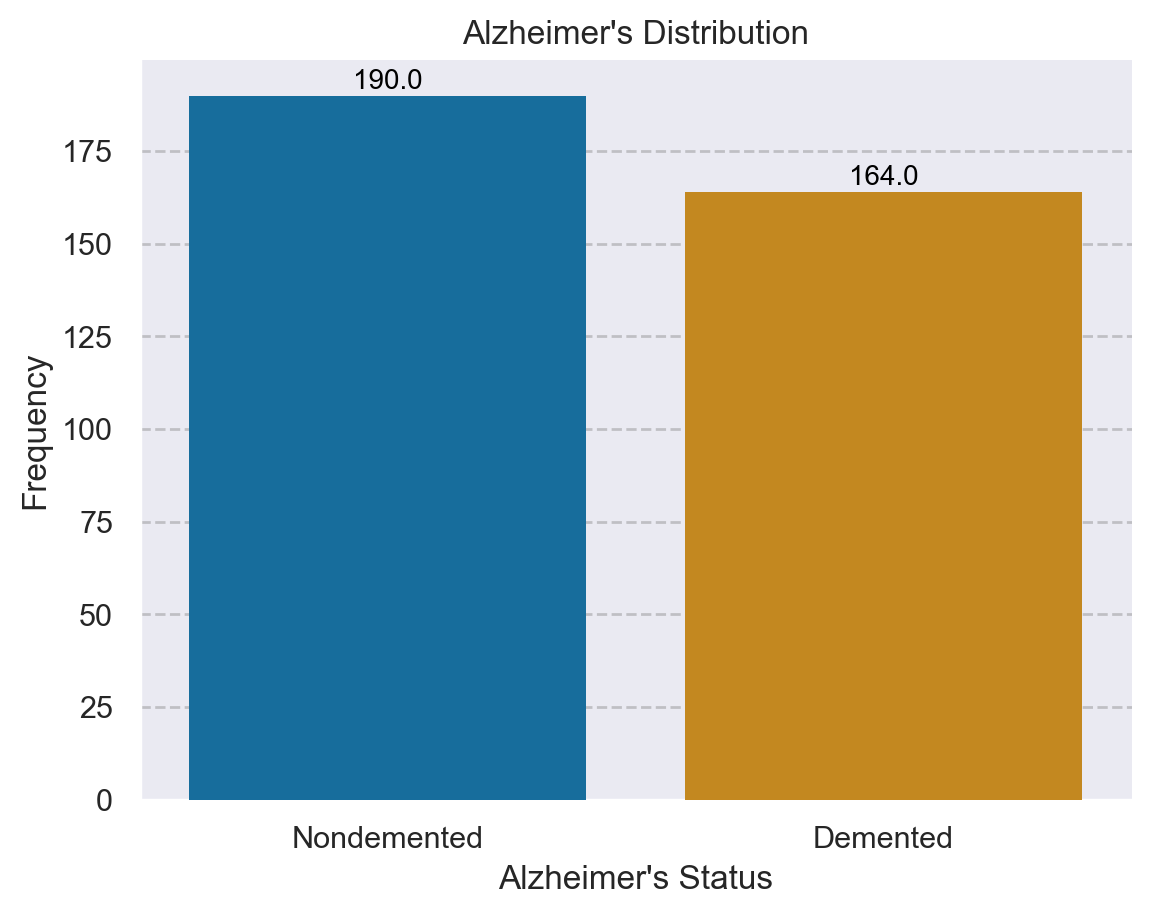

In [72]:
# Create a bar plot of the categories of the `GroupSimple` column using seaborn
# Add the title "Alzheimer's Distribution" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Add the frequency of each bar on top of the bars
# Remove the right and top spines
sns.countplot(data=df, x='GroupSimple', palette='colorblind', edgecolor='none', zorder=3, hue='GroupSimple', dodge=False)
plt.title('Alzheimer\'s Distribution')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('Frequency')
# Use grey for the grid lines
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
sns.despine() 

plt.show()

There are more nondemented patients than patients with Alzheimer's, though the difference is not too great. 

#### Age

The `Age` column contains information about the patient's age in years. 

In [73]:
# Calculate summary statistics of the `Age` column
df['Age'].describe()

count    354.000000
mean      77.033898
std        7.811808
min       60.000000
25%       71.000000
50%       77.000000
75%       82.000000
max       98.000000
Name: Age, dtype: float64

The average age of patients in the dataset is $77.03$ with a standard deviation of $7.81$. The ages range from $60-98$ years old. The median age is $77$, the $25^{th}$ percentile age is $71$, and the $75^{th}$ percentile age is $88$. 

In [76]:
# Calculate the interquartile range of the `Age` column using the stats module
stats.iqr(df['Age'])

np.float64(11.0)

The interquartile range of the patient ages is $11.0$. 

In [77]:
# Calculate summary statistics of the `Age` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['Age'].describe()

,count,mean,std,min,25%,50%,75%,max
GroupSimple,,,,,,,,
Demented,164.0,77.006098,7.493553,61.0,71.0,77.0,82.25,98.0
Nondemented,190.0,77.057895,8.096104,60.0,71.0,77.0,82.00,97.0


For the demented patients, their mean age is $77.01$ with a standard deviation of $7.49$, median age is $77$,  $25^{th}$ percentile age is $71$,  $75^{th}$ percentile age is $82.25$, and age range is $61-98$ years old. For the nondemented patients, their mean age is $77.06$ with a standard deviation of $8.10$, median age is $77$,  $25^{th}$ percentile age is $71$,  $75^{th}$ percentile age is $82.00$, and age range is $60-97$ years old. 

In [78]:
# Use the stats module to calculate the interquartile range for each category of the `GroupSimple` column
df.groupby('GroupSimple')['Age'].apply(stats.iqr)

GroupSimple
Demented       11.25
Nondemented    11.00
Name: Age, dtype: float64

For the demented patients, their ages' interquartile range is $11.25$. For the nondemented patients, their ages' interquartile range is $11.0$.

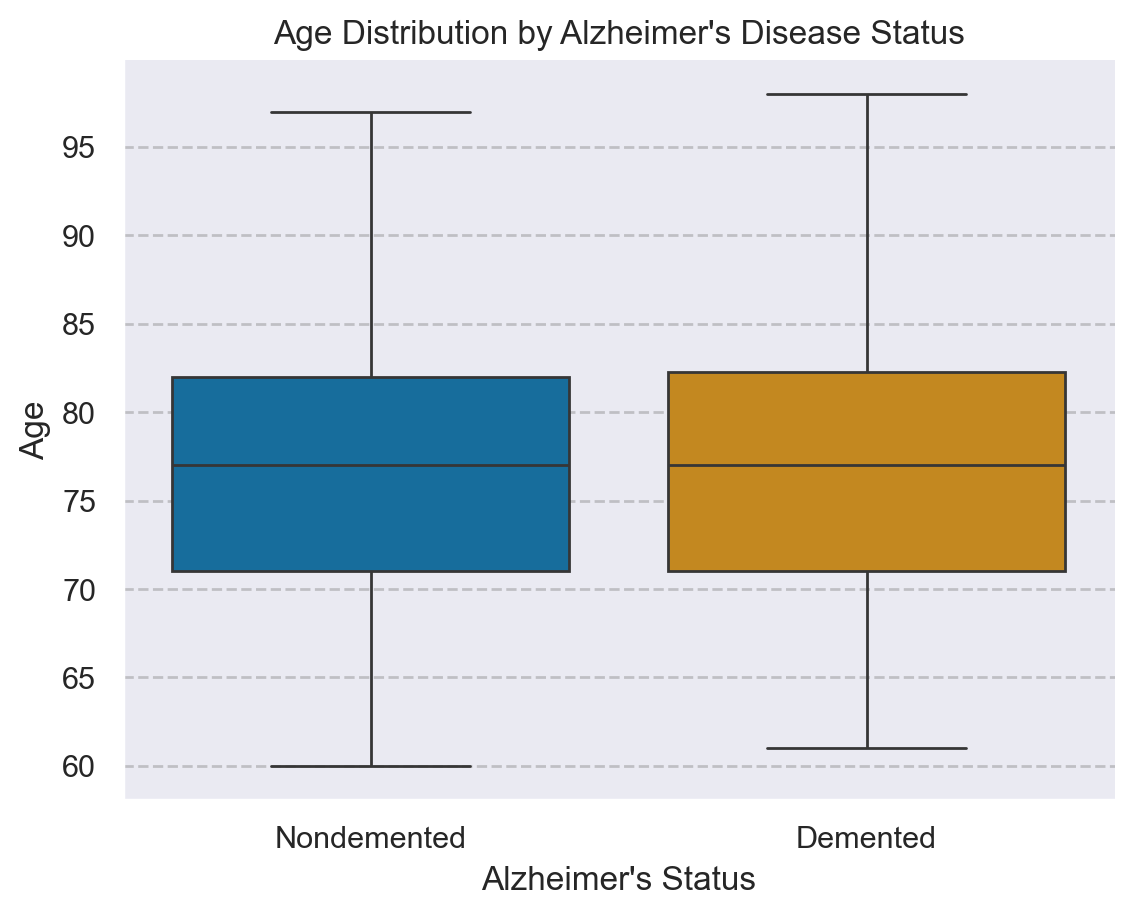

In [ ]:
# Create a box-and-whisker plot of the `Age` column for each category of the `GroupSimple` column using seraborn
# Add the title "Age Distribution by Alzheimer's Disease Status" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Remove the right and top spines
# show outliers in the boxplot and use the colorblind palette
sns.boxplot(data=df, x='GroupSimple', y='Age', palette='colorblind', hue='GroupSimple', dodge=False, zorder=3, showfliers=True)
plt.title('Age Distribution by Alzheimer\'s Disease Status')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('Age')
# Use grey for the grid lines
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
sns.despine()
plt.show()

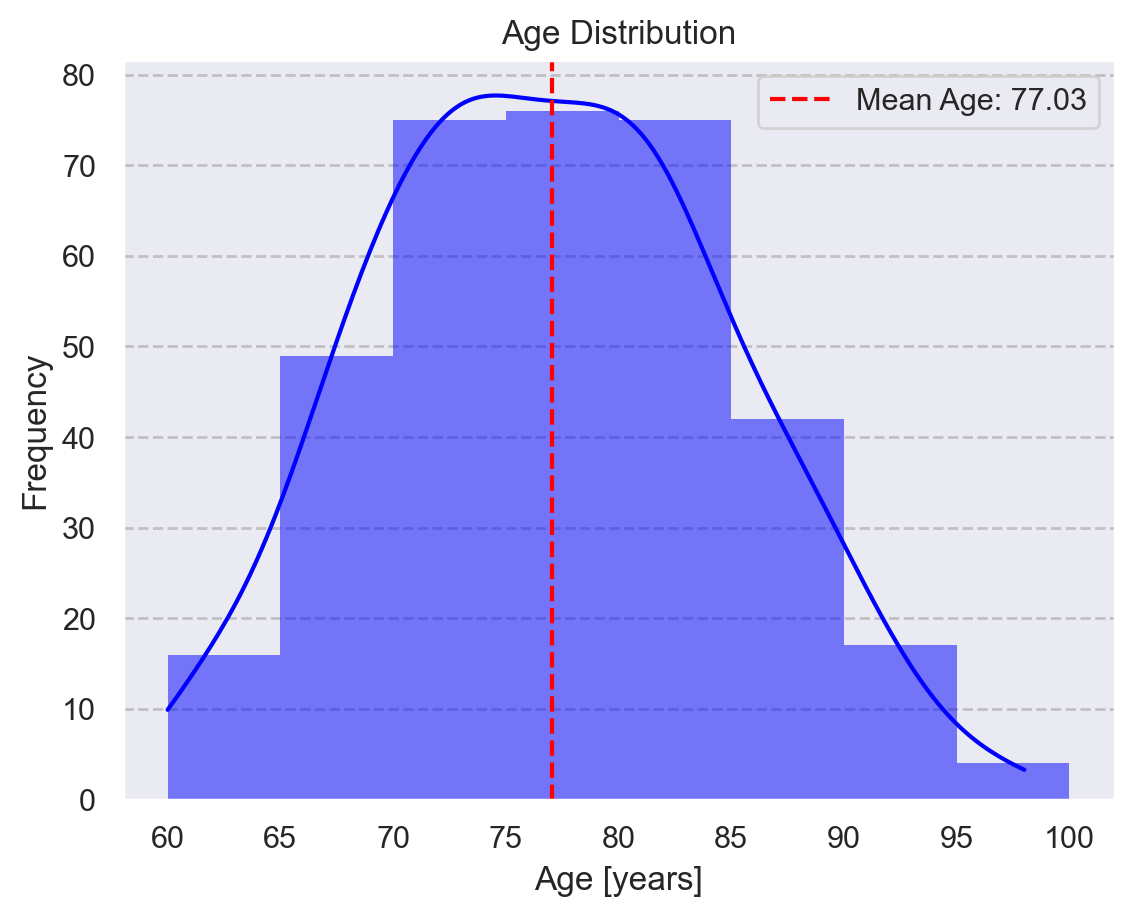

In [100]:
# Create a histogram of the `age` column
# Add the title "Age Distribution"
# Add the horixontal grid to the plot
# Age the horizontal axis label "Age [years]"
# Add the vertical axis label "Frequency"
# Change the binwidth from 60 to 65, 65 to 70, 70 to 75, 75 to 80, 80 to 85, 85 to 90, 90 to 95, and 95 to 100.
# Add a KDE curve to the histogram
# Add a vertical red line to indicate the mean, and add a legend
mean_age = df['Age'].mean()
sns.histplot(data=df, x='Age', bins=[60, 65, 70, 75, 80, 85, 90, 95, 100], kde=True, color='blue', edgecolor='none')
plt.title('Age Distribution')
plt.xlabel('Age [years]')
plt.ylabel('Frequency')
# Use grey for the grid lines
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean Age: {mean_age:.2f}')
plt.legend()
plt.show()

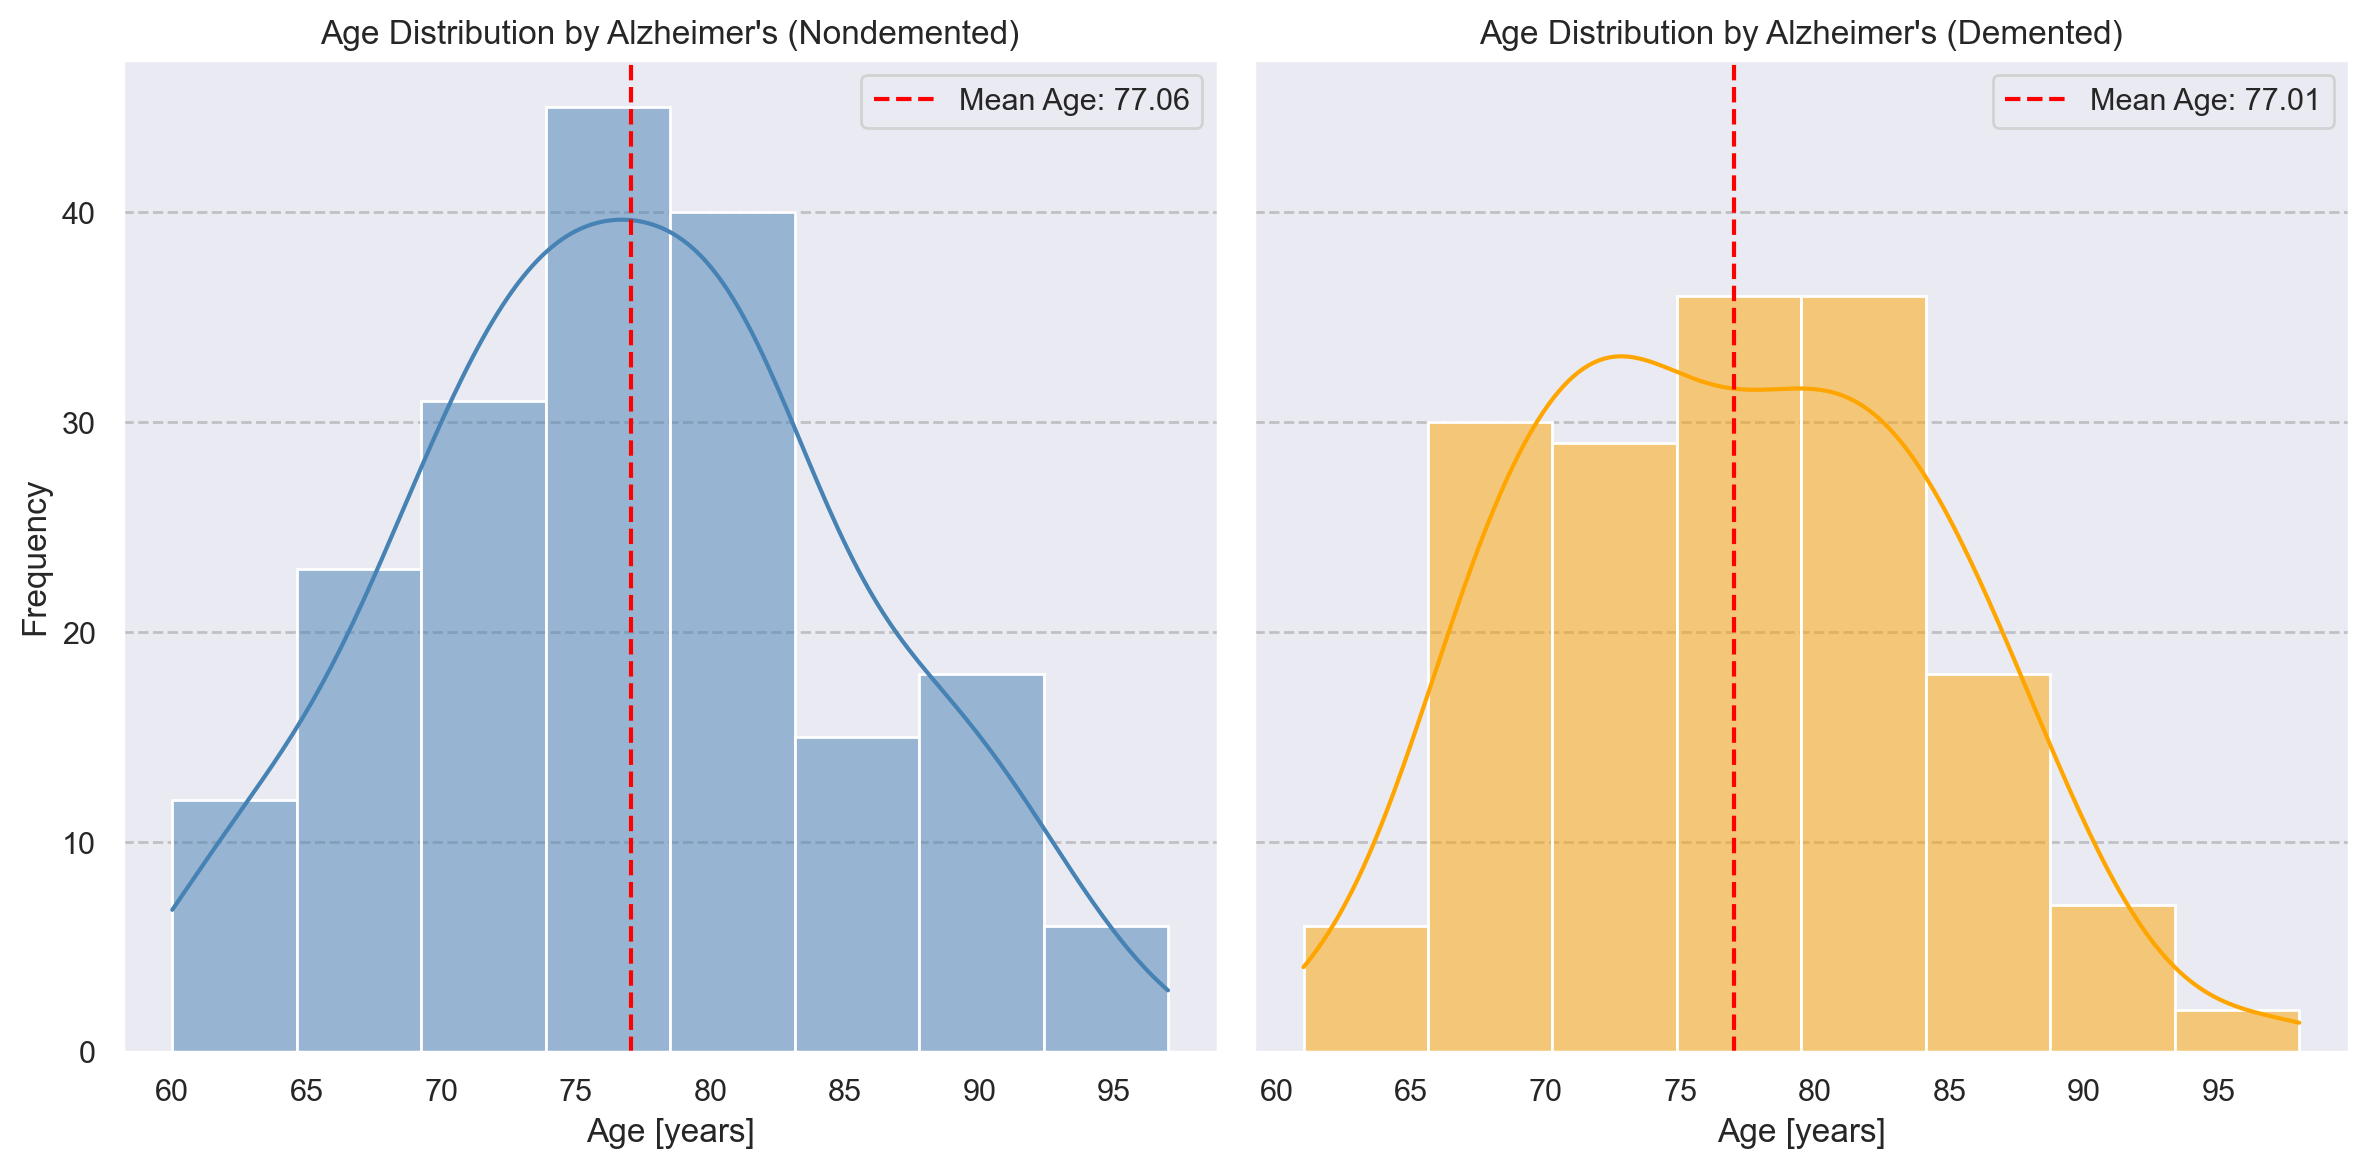

In [ ]:
# Recreate the previous histogram, but this time create a separate histogram for each group in the `GroupSimple` column. Use seaborn. 
# Create the 2 plots in a single row and 2 columns
# Add the title for one plot as  "Age Distribution by Alzheimer's (Nondemented)", and the other plot as "Age Distribution by Alzheimer's (Demented)"
# Add the horixontal grid to the plot
# Age the horizontal axis label "Age [years]"
# Add the vertical axis label "Frequency"
# Add a legend to indicate the mean age for each group
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

mean_age_demented = df.groupby('GroupSimple')['Age'].mean()['Demented']
mean_age_nondemented = df.groupby('GroupSimple')['Age'].mean()['Nondemented']

sns.histplot(data=df[df['GroupSimple'] == 'Nondemented'], x='Age', bins=8, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Age Distribution by Alzheimer's (Nondemented)")
axes[0].set_xlabel('Age [years]')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=.4, color='grey')
axes[0].set_axisbelow(True)
axes[0].axvline(mean_age_nondemented, color='red', linestyle='--', label=f'Mean Age: {mean_age_nondemented:.2f}')
axes[0].legend()

sns.histplot(data=df[df['GroupSimple'] == 'Demented'], x='Age', bins=8, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Age Distribution by Alzheimer's (Demented)")
axes[1].set_xlabel('Age [years]')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=.4, color='grey')
axes[1].set_axisbelow(True)
axes[1].axvline(mean_age_demented, color='red', linestyle='--', label=f'Mean Age: {mean_age_demented:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

#### Gender: M/F

The `M/D` column contains information about the patient's binary gender: either Male or Female. 

In [84]:
# Return the unique values in the `M/F` column
df['M/F'].unique()

array(['M', 'F'], dtype=object)

Male patients are demoted as `M`. Female patients are denoted as `F`. 

In [85]:
# Calculate the frequency of each category in the `M/F` column
df['M/F'].value_counts()

M/F
F    204
M    150
Name: count, dtype: int64

Of the $354$ patients, $204$ are female and $150$ are male. 

In [86]:
# Calculate the percentage of each category in the `M/F` column
df['M/F'].value_counts(normalize=True) * 100

M/F
F    57.627119
M    42.372881
Name: proportion, dtype: float64

Of the $354$ patients, $57.63\%$ are female and $42.37\%$ are male. 

In [87]:
# Calculate the frequency of the categories in the `M/F` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['M/F'].value_counts()

GroupSimple  M/F
Demented     M       89
             F       75
Nondemented  F      129
             M       61
Name: count, dtype: int64

$89$ patients are male and demented. $75$ patients are female and demented. $129$ patients are female and not demented. $61$ patients are male and not demented. 

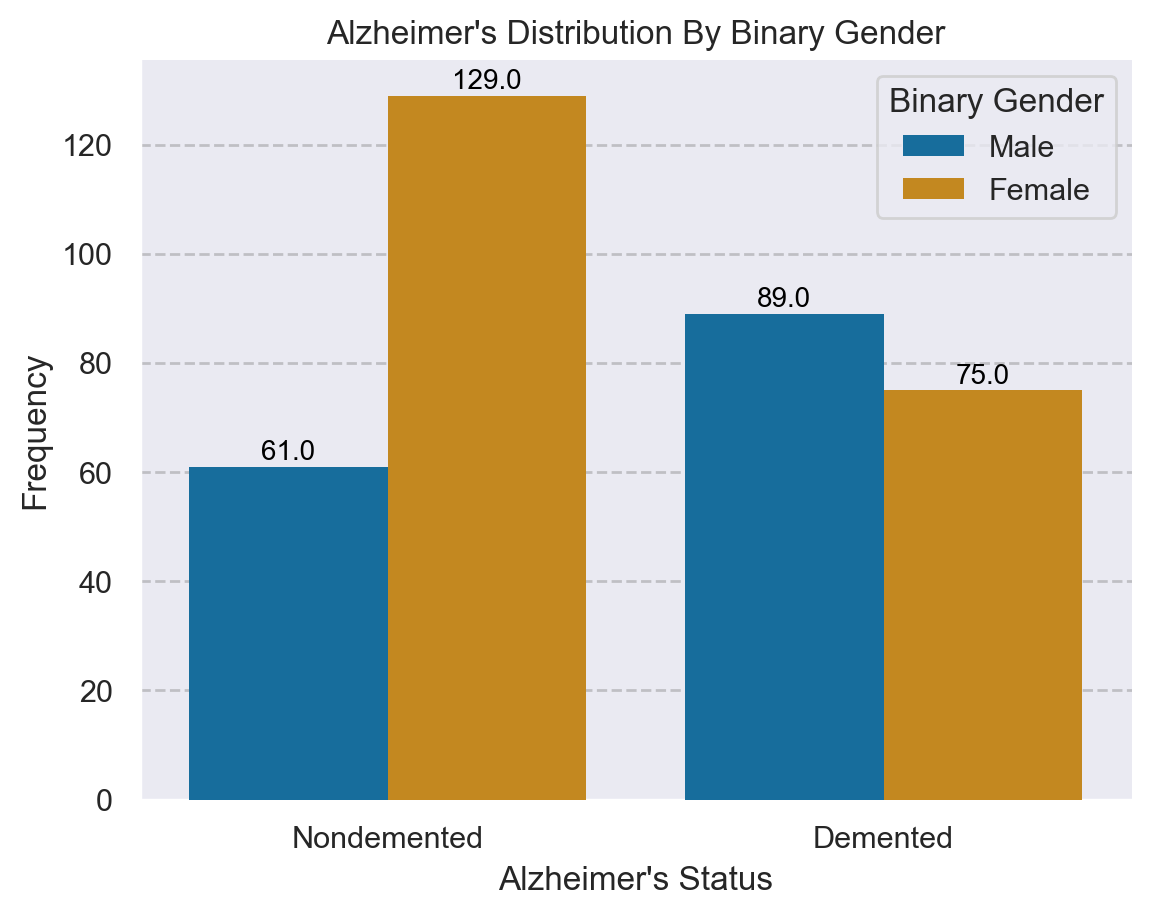

In [93]:
# Create a stacked bar plot showing the proportions of each `M/F` category within each `GroupSimple` category using seaborn
# Add the title "Alzheimer's Distribution By Binary Gender" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Add the frequency of each bar on top of the bars
# Remove the right and top spines
# Use grey for the grid lines
sns.countplot(data=df, x='GroupSimple', palette='colorblind', edgecolor='none', zorder=3, hue='M/F')
plt.title('Alzheimer\'s Distribution By Binary Gender')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
sns.despine()

# In the legend, Chame M to Male and F to Female
plt.legend(title='Binary Gender', labels=['Male', 'Female'])

plt.show()

#### Education

The `EDUC` column contains information about the years of education the patient has. 

In [94]:
# Calculate summary statistics of the `EDUC` column
df['EDUC'].describe()

count    354.000000
mean      14.703390
std        2.895662
min        6.000000
25%       12.000000
50%       15.000000
75%       16.750000
max       23.000000
Name: EDUC, dtype: float64

The average years of education patient have in the dataset is $14.70$ with a standard deviation of $2.90$. The yeard of education ranges from $6-23$ years. The median years of education is $15$, the $25^{th}$ percentile age years of education is $12$, and the $75^{th}$ percentile years of education is $16.75$. 

In [95]:
# Calculate the interquartile range of the `EDUC` column using the stats module
stats.iqr(df['EDUC'])

np.float64(4.75)

The interquartile range of the patient years of education is $4.75$. 

In [96]:
# Calculate summary statistics of the `EDUC` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['EDUC'].describe()

,count,mean,std,min,25%,50%,75%,max
GroupSimple,,,,,,,,
Demented,164.0,14.195122,2.992584,6.0,12.0,14.0,16.0,20.0
Nondemented,190.0,15.142105,2.742149,8.0,13.0,16.0,18.0,23.0


For the demented patients, their mean number of years of education is $14.20$ with a standard deviation of $2.99$, median years of education is $14$,  $25^{th}$ percentile years of education is $12$,  $75^{th}$ percentile years of education is $16$, and years of education range is $6-20$ years. For the nondemented patients, their mean number of years of education is $15.14$ with a standard deviation of $2.74$, median years of education is $16$,  $25^{th}$ percentile is $13$,  $75^{th}$ percentile years of education is $18.00$, and years of education range is $8-23$ years. 

In [97]:
# Use the stats module to calculate the interquartile range for each category of the `GroupSimple` column
df.groupby('GroupSimple')['EDUC'].apply(stats.iqr)

GroupSimple
Demented       4.0
Nondemented    5.0
Name: EDUC, dtype: float64

For the demented patients, their years of educations' interquartile range is $4$. For the nondemented patients, their years of educations' interquartile range is $5$.

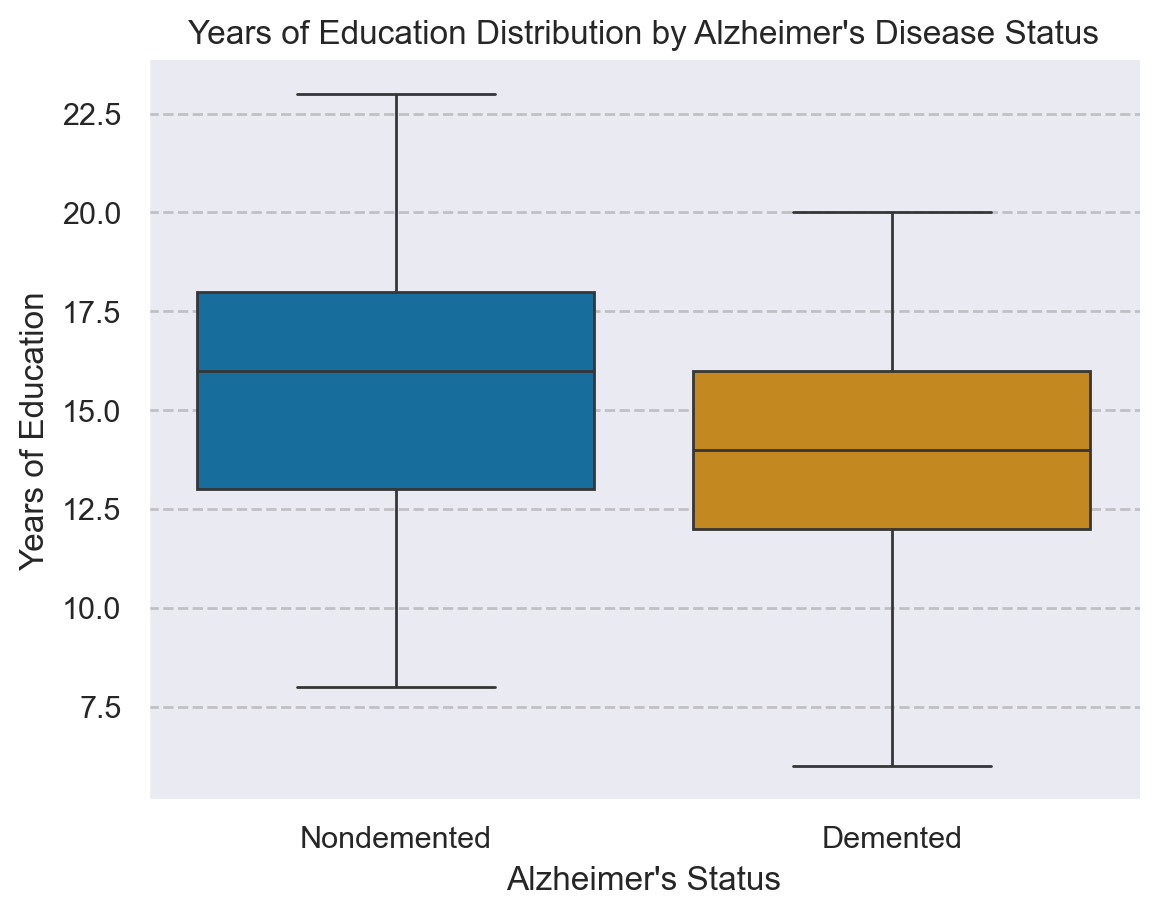

In [106]:
# Create a box-and-whisker plot of the `EDUC` column for each category of the `GroupSimple` column using seraborn
# Add the title "Years of Education Distribution by Alzheimer's Disease Status" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Remove the right and top spines
# show outliers in the boxplot and use the colorblind palette
sns.boxplot(data=df, x='GroupSimple', y='EDUC', palette='colorblind', hue='GroupSimple', dodge=False, zorder=3, showfliers=True)
plt.title('Years of Education Distribution by Alzheimer\'s Disease Status')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('Years of Education')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
sns.despine()
plt.show()

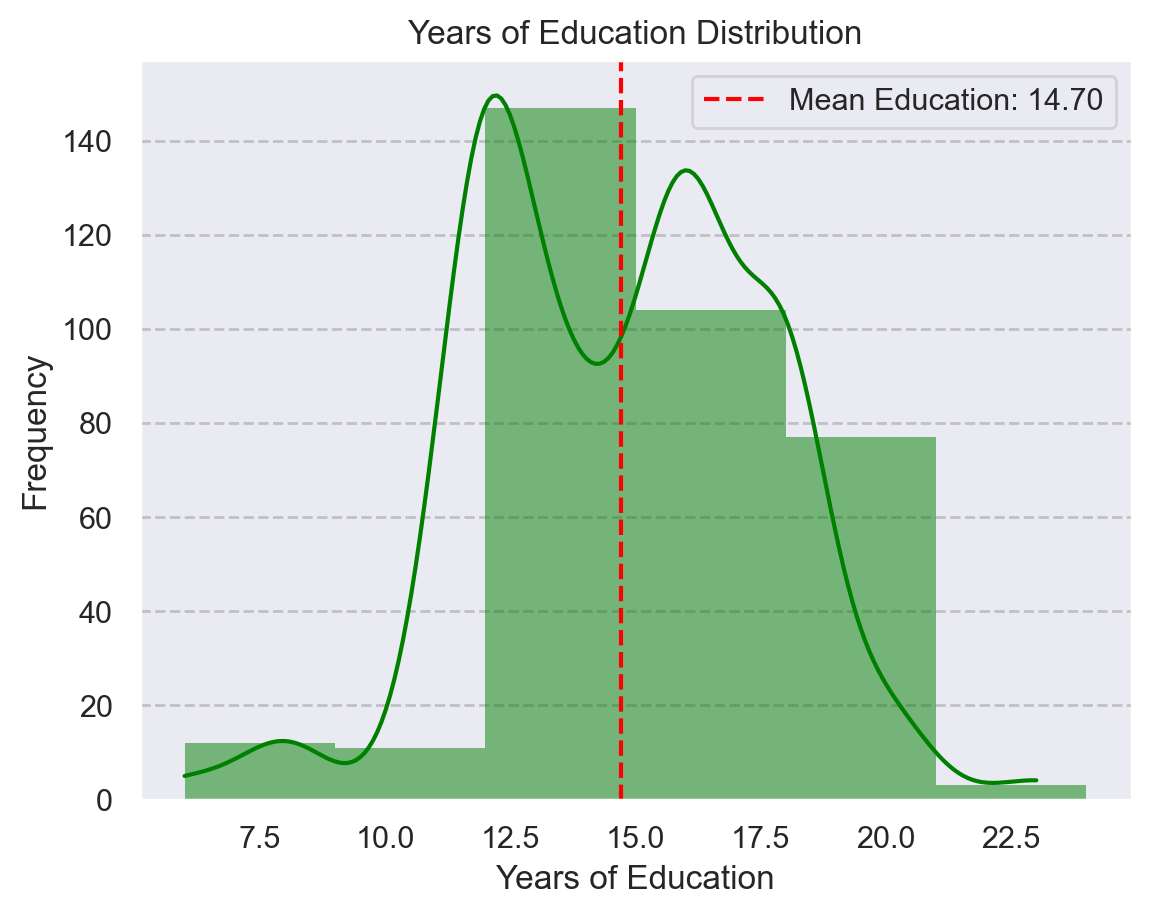

In [113]:
# Create a histogram of the `EDUC` column
# Add the title "Age Distribution"
# Add the horixontal grid to the plot
# Age the horizontal axis label "Age [years]"
# Add the vertical axis label "Frequency"
# Change the binwidth to be in increments of 5 from 0 to 25.
# Add a KDE curve to the histogram
# Add a vertical red line to indicate the mean, and add a legend
mean_educ = df['EDUC'].mean()
sns.histplot(data=df, x='EDUC', bins=[6, 9, 12, 15, 18, 21, 24], kde=True, color='green', edgecolor='none')
plt.title('Years of Education Distribution')
plt.xlabel('Years of Education')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
plt.axvline(mean_educ, color='red', linestyle='--', label=f'Mean Education: {mean_educ:.2f}')
plt.legend()
plt.show()

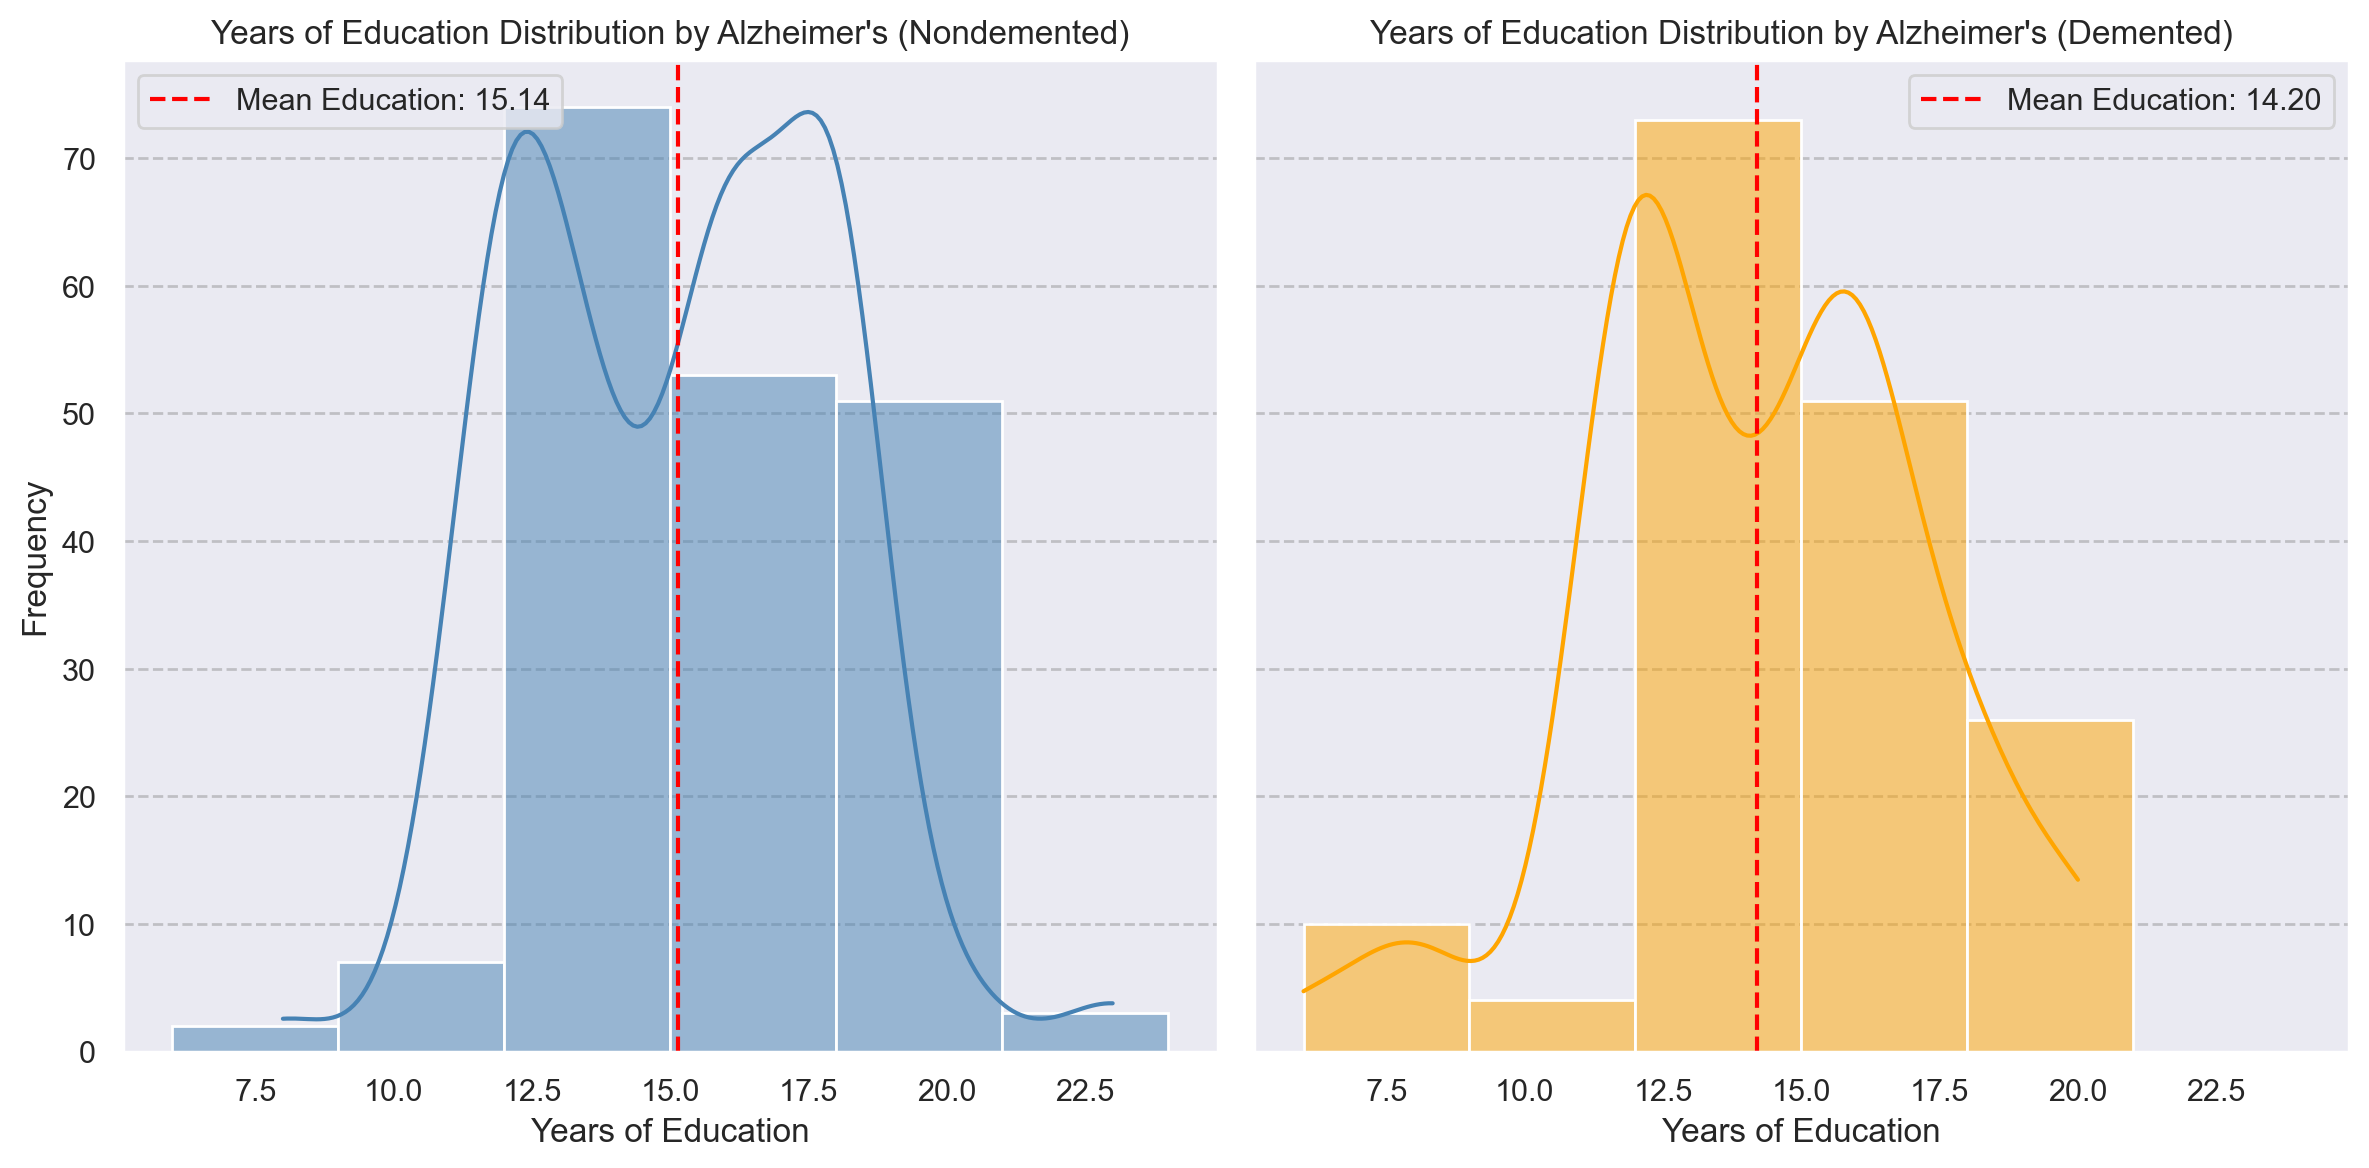

In [114]:
# Recreate the previous histogram, but this time create a separate histogram for each group in the `GroupSimple` column. Use seaborn. 
# Create the 2 plots in a single row and 2 columns
# Add the title for one plot as  "Age Distribution by Alzheimer's (Nondemented)", and the other plot as "Age Distribution by Alzheimer's (Demented)"
# Add the horixontal grid to the plot
# Age the horizontal axis label "Age [years]"
# Add the vertical axis label "Frequency"
# Add a legend to indicate the mean age for each group
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

mean_educ_demented = df.groupby('GroupSimple')['EDUC'].mean()['Demented']
mean_educ_nondemented = df.groupby('GroupSimple')['EDUC'].mean()['Nondemented']

sns.histplot(data=df[df['GroupSimple'] == 'Nondemented'], x='EDUC', bins=[6, 9, 12, 15, 18, 21, 24], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Years of Education Distribution by Alzheimer's (Nondemented)")
axes[0].set_xlabel('Years of Education')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=.4, color='grey')
axes[0].set_axisbelow(True)
axes[0].axvline(mean_educ_nondemented, color='red', linestyle='--', label=f'Mean Education: {mean_educ_nondemented:.2f}')
axes[0].legend()

sns.histplot(data=df[df['GroupSimple'] == 'Demented'], x='EDUC', bins=[6, 9, 12, 15, 18, 21, 24], kde=True, ax=axes[1], color='orange')
axes[1].set_title("Years of Education Distribution by Alzheimer's (Demented)")
axes[1].set_xlabel('Years of Education')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=.4, color='grey')
axes[1].set_axisbelow(True)
axes[1].axvline(mean_educ_demented, color='red', linestyle='--', label=f'Mean Education: {mean_educ_demented:.2f}')
axes[1].legend()
plt.tight_layout()
plt.show()

#### Socioeconomic Status

The `SES` column provides information on patients' socioeconomic status (SES) on a scale of whole numbers $1-5$, where $1$ is the lowest status and $5$ is the highest. This is a categorical variable, despite being represented by numbers, because each status is its own group and those numbers stand for "low," "medium," "high," etc.

In [115]:
# Return the unique values in the `SES` column
df['SES'].unique()

array([2., 3., 4., 1., 5.])

Socioeconomic status is $1-5$ with $1$ as the lowest and $5$ as the highest. 

In [116]:
# Calculate the frequency of each category in the `SES` column
df['SES'].value_counts()

SES
2.0    103
1.0     88
3.0     82
4.0     74
5.0      7
Name: count, dtype: int64

Of the $354$ patients, $103$ fall in SES $2$, $88$ fall in SES $1$, $82$ fall in SES $3$, $74$ fall in SES $4$, and $7$ fall in SES $5$. 

In [117]:
# Calculate the percentage of each category in the `SES` column
df['SES'].value_counts(normalize=True) * 100

SES
2.0    29.096045
1.0    24.858757
3.0    23.163842
4.0    20.903955
5.0     1.977401
Name: proportion, dtype: float64

Of the $354$ patients, $29.10\%$ fall in SES $2$, $24.86\%$ fall in SES $1$, $23.16\%$ fall in SES $3$, $20.90\%$ fall in SES $4$, and $1.98\%$ fall in SES $5$. 

In [118]:
# Calculate the frequency of the categories in the `SES` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['SES'].value_counts()

GroupSimple  SES
Demented     1.0    47
             3.0    40
             4.0    40
             2.0    32
             5.0     5
Nondemented  2.0    71
             3.0    42
             1.0    41
             4.0    34
             5.0     2
Name: count, dtype: int64

For the demented patients, $47$ were in SES $1$, $40$ were in SES $3$, $40$ were in SES $4$, $32$ were in SES $2$, and $5$ were in SES $5$. For the nondemented patients, $71$ were in SES $2$, $42$ were in SES $3$, $41$ were in SES $1$, $34$ were in SES $4$, and $2$ were in SES $5$.

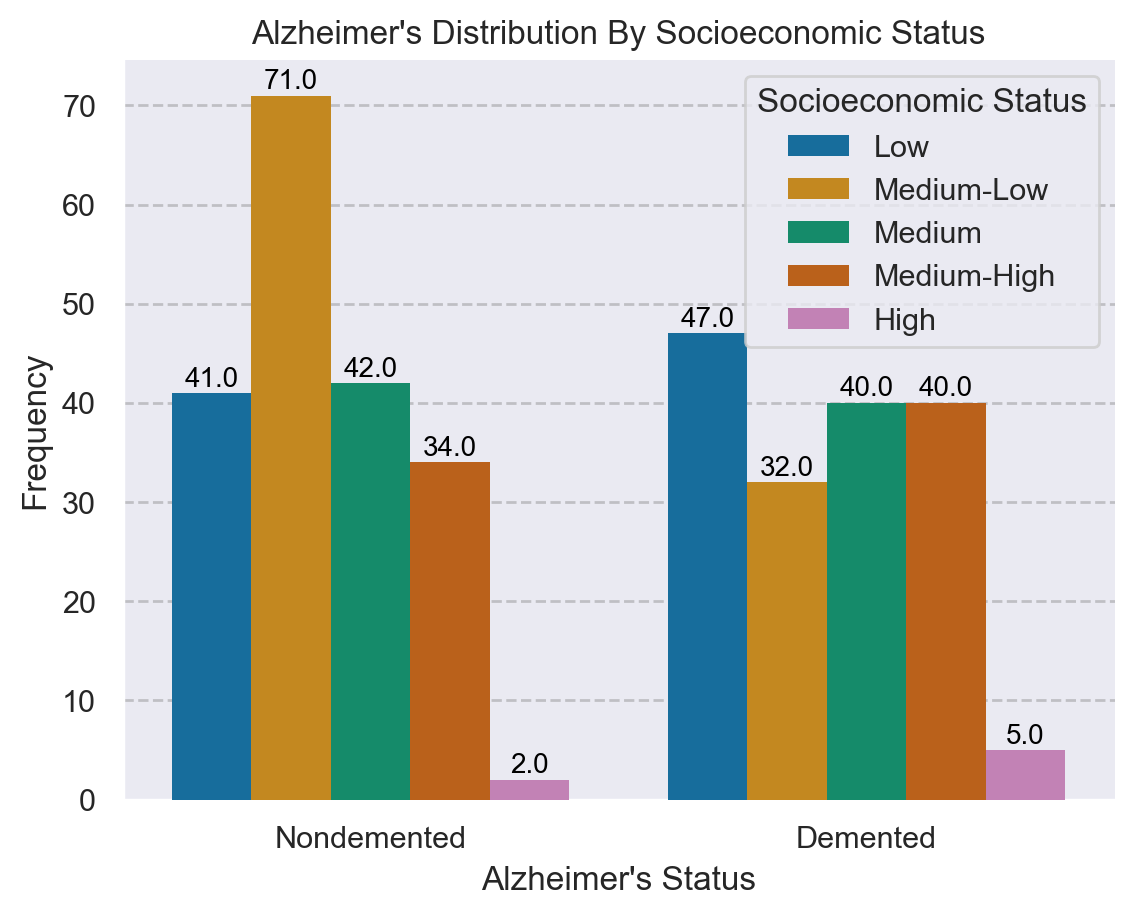

In [119]:
# Create a stacked bar plot showing the proportions of each `SES` category within each `GroupSimple` category using seaborn
# Add the title "Alzheimer's Distribution By Socioeconomic Status" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Add the frequency of each bar on top of the bars
# Remove the right and top spines
# Use grey for the grid lines
# Add a legend. Label 1 as "Low", 2 as "Medium-Low", 3 as "Medium", 4 as "Medium-High", and 5 as "High" 
sns.countplot(data=df, x='GroupSimple', palette='colorblind', edgecolor='none', zorder=3, hue='SES')
plt.title('Alzheimer\'s Distribution By Socioeconomic Status')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.legend(title='Socioeconomic Status', labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])
plt.show() 


The socioeconomic statuses will now be split into $2$ groups: `Low` and `High`. `Low` will consists of statuses $1$ and $2$. `High` will consist of $3$, $4$, and $5$. Having only $2$ groups wil aid in future analysis. Status $3$ is grouped in `High` rather than `Low` because to avoid biasing th results from the low amount of status $5$ patients in the dataset. 

In [143]:
# Create a new column in df called `SES_2_Groups` that contains the values of `SES` with the following mapping:
# - '1' -> 'low'
# - '2' -> 'low'
# - '3' -> 'high'
# - '4' -> 'high'
# - '5' -> 'high'
df['SES_2_Groups'] = df['SES'].map({1: 'Low', 2: 'Low', 3: 'High', 4: 'High', 5: 'High'})

In [145]:
# Return the unique values of the `SES_2_Groups` column
df['SES_2_Groups'].unique()

array(['Low', 'High'], dtype=object)

The `SES_2_Groups` colums contains $2$ SES groups: `Low` and `High`. 

In [146]:
# Calculate the frequency of each category in the `SES_2_Groups` column
df['SES_2_Groups'].value_counts()

SES_2_Groups
Low     191
High    163
Name: count, dtype: int64

Of the $354$ patients, $191$ are in a low SES group and $163$ are in a high SES group. 

In [147]:
# Calculate the percentage of each category in the `SES_2_Groups` column
df['SES_2_Groups'].value_counts(normalize=True) * 100

SES_2_Groups
Low     53.954802
High    46.045198
Name: proportion, dtype: float64

Of the $354$ patients, $53.95\%$ are in a low SES group and $46.05\%$ are in a high SES group. 

In [148]:
# Calculate the frequency of the categories in the `SES_2_Groups` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['SES_2_Groups'].value_counts()

GroupSimple  SES_2_Groups
Demented     High             85
             Low              79
Nondemented  Low             112
             High             78
Name: count, dtype: int64

For the demented patients, $85$ were in a high ses group, while $79$ were in a low SES group. For the nondemented patients, $112$ were in a low ses group, while $78$ were in a low SES group.

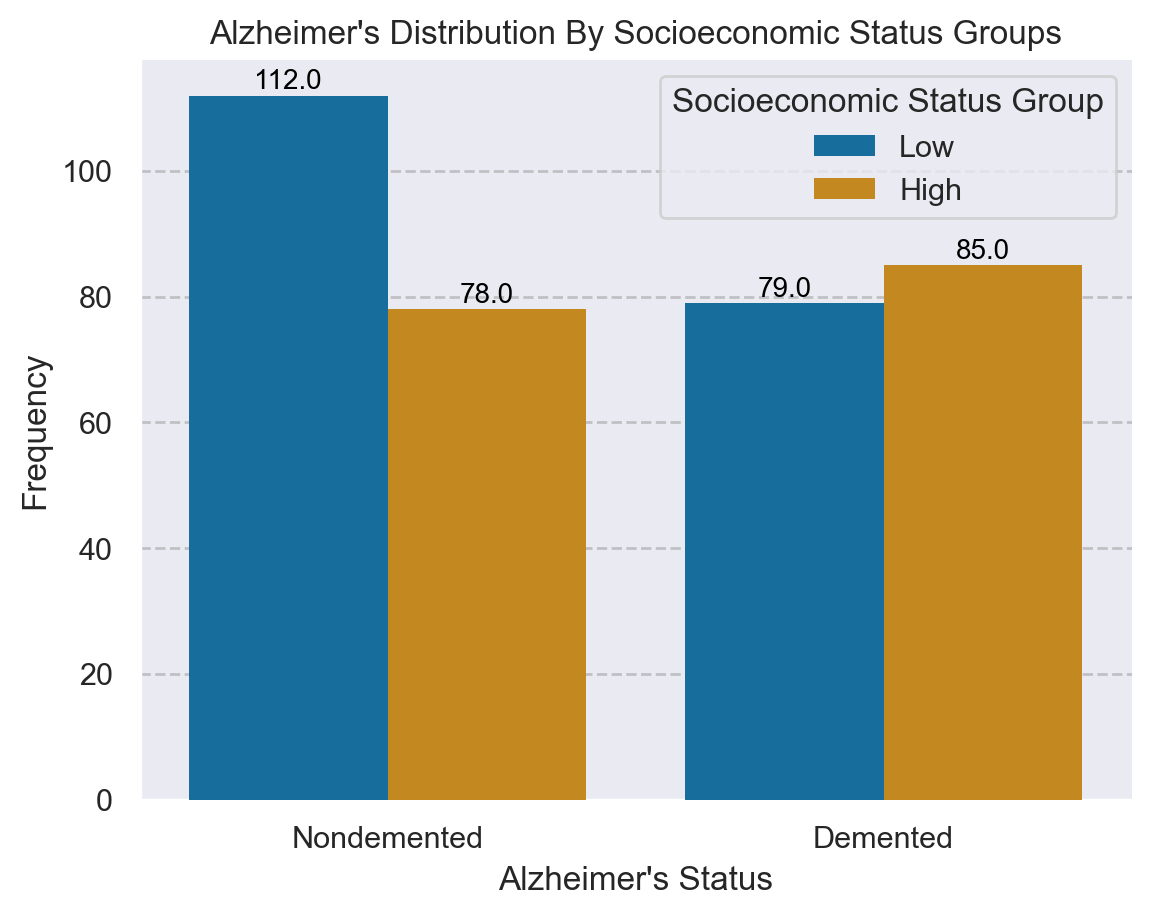

In [151]:
# Create a stacked bar plot showing the proportions of each `SES_2_Groups` category within each `GroupSimple` category using seaborn
# Add the title "Alzheimer's Distribution By Socioeconomic Status Groups" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Add the frequency of each bar on top of the bars
# Remove the right and top spines
# Use grey for the grid lines
# Add a legend.
sns.countplot(data=df, x='GroupSimple', palette='colorblind', edgecolor='none', zorder=3, hue='SES_2_Groups')
plt.title('Alzheimer\'s Distribution By Socioeconomic Status Groups')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points')
sns.despine()
plt.legend(title='Socioeconomic Status Group', labels=['Low', 'High'])
plt.show()

#### Mini Mental State Examination

The `MMSE` column contains information about the patients' mini mental state examination scores. 

In [120]:
# Calculate summary statistics of the `MMSE` column
df['MMSE'].describe()

count    354.000000
mean      27.409605
std        3.712626
min        4.000000
25%       27.000000
50%       29.000000
75%       30.000000
max       30.000000
Name: MMSE, dtype: float64

The average MMSE score of patients in the dataset is $27.41$ with a standard deviation of $3.71$. The MMSE scores range from $4-30$. The median score is $29$, the $25^{th}$ percentile score is $27$, and the $75^{th}$ percentile age is $30$. 

In [121]:
# Calculate the interquartile range of the `MMSE` column using the stats module
stats.iqr(df['MMSE'])

np.float64(3.0)

The interquartile range of the patient MMSE scores is $3$. 

In [122]:
# Calculate summary statistics of the `MMSE` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['MMSE'].describe()

,count,mean,std,min,25%,50%,75%,max
GroupSimple,,,,,,,,
Demented,164.0,25.304878,4.543421,4.0,23.0,26.5,29.0,30.0
Nondemented,190.0,29.226316,0.882722,26.0,29.0,29.0,30.0,30.0


For the demented patients, their mean MMSE score is $25.30$ with a standard deviation of $4.54$, median score is $26.5$,  $25^{th}$ percentile score is $23$,  $75^{th}$ percentile score is $29$, and score range is $23-30$. For the nondemented patients, their mean MMSE score is $29.23$ with a standard deviation of $0.88$, median score is $29$,  $25^{th}$ percentile score is $29$,  $75^{th}$ percentile score is $30$, and score range is $26-30$. 

In [123]:
# Use the stats module to calculate the interquartile range for each category of the `GroupSimple` column
df.groupby('GroupSimple')['MMSE'].apply(stats.iqr)

GroupSimple
Demented       6.0
Nondemented    1.0
Name: MMSE, dtype: float64

For the demented patients, their MMSE scores' interquartile range is $6$. For the nondemented patients, their MSE scores' interquartile range is $1$.

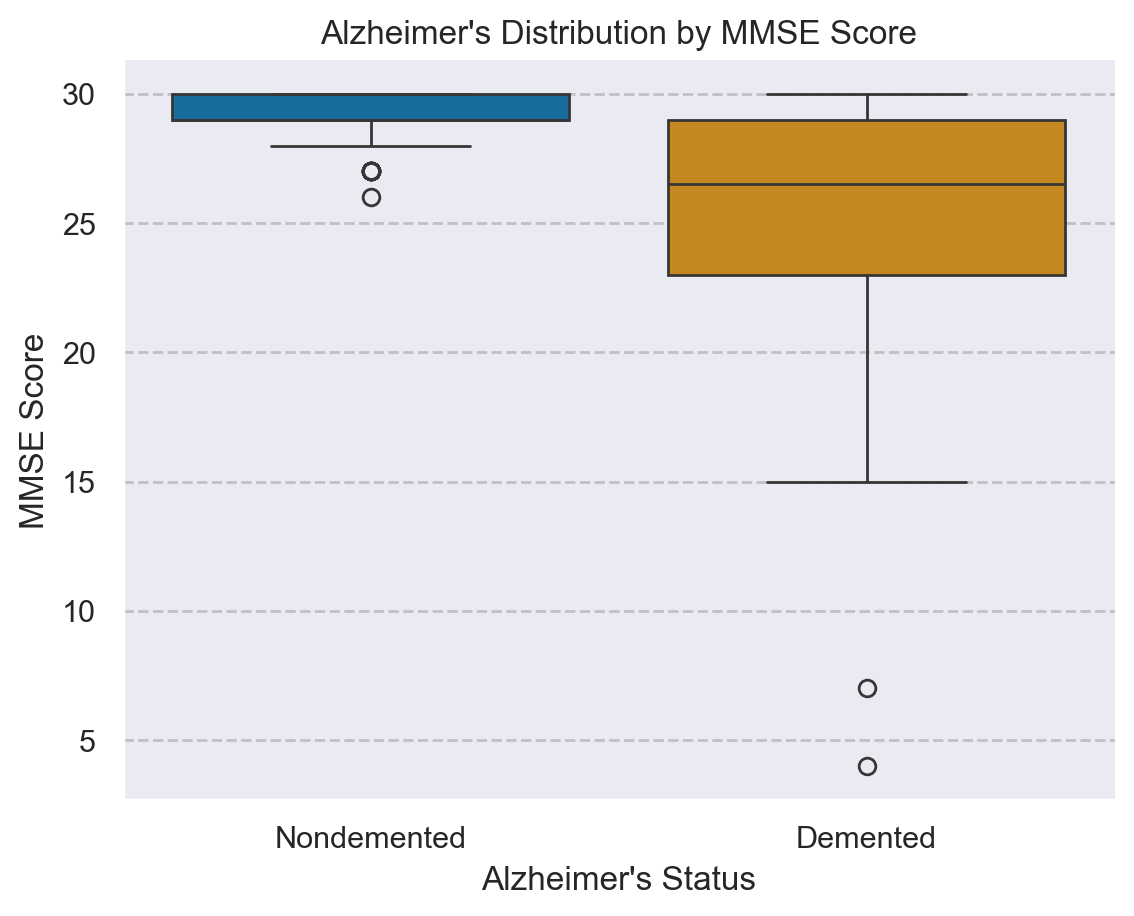

In [142]:
# Create a box-and-whisker plot of the `MMSE` column for each category of the `GroupSimple` column using seraborn
# Add the title "Age Distribution by MMSE Score" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Remove the right and top spines
# show outliers in the boxplot and use the colorblind palette
sns.boxplot(data=df, x='GroupSimple', y='MMSE', palette='colorblind', hue='GroupSimple', dodge=False, zorder=3, showfliers=True)
plt.title('Alzheimer\'s Distribution by MMSE Score')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('MMSE Score')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
sns.despine()
plt.show()

#### Clinical Dementia Rating

The `CDR` column contains information about the patients' clinical dementia rating. 

In [127]:
# Calculate summary statistics of the `CDR` column
# Use at least 5 decimal places for the percentiles, min, and max
df['CDR'].describe().round(5)

count    354.00000
mean       0.27119
std        0.37054
min        0.00000
25%        0.00000
50%        0.00000
75%        0.50000
max        2.00000
Name: CDR, dtype: float64

The average CDR of patients in the dataset is $0.27$ with a standard deviation of $0.37$. The CDRs range from $0-2$. The median rating is $0$, the $25^{th}$ percentile rating is $0$, and the $75^{th}$ percentile rating is $.5$. 

In [128]:
# Calculate the interquartile range of the `CDR` column using the stats module
stats.iqr(df['CDR'])

np.float64(0.5)

The interquartile range of the patient CDRs is $0.5$. 

In [130]:
# Calculate summary statistics of the `CDR` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['CDR'].describe().round(5)

,count,mean,std,min,25%,50%,75%,max
GroupSimple,,,,,,,,
Demented,164.0,0.57927,0.34114,0.0,0.5,0.5,0.5,2.0
Nondemented,190.0,0.00526,0.05116,0.0,0.0,0.0,0.0,0.5


For the demented patients, their mean CDR is $0.58$ with a standard deviation of $0.34$, median rating is $0.5$,  $25^{th}$ percentile rating is $0.5$,  $75^{th}$ percentile rating is $0.5$, and rating range is $0-2$. For the nondemented patients, their mean CDR rating is $0.01$ with a standard deviation of $0.05$, median rating is $0$,  $25^{th}$ percentile rating is $0$,  $75^{th}$ percentile rating is $0$, and rating range is $0-0.5$. 

In [131]:
# Use the stats module to calculate the interquartile range for each category of the `GroupSimple` column
df.groupby('GroupSimple')['CDR'].apply(stats.iqr)

GroupSimple
Demented       0.0
Nondemented    0.0
Name: CDR, dtype: float64

For the demented patients, their CDRs' interquartile range is $0$. For the nondemented patients, their CDRs' interquartile range is also $0$.

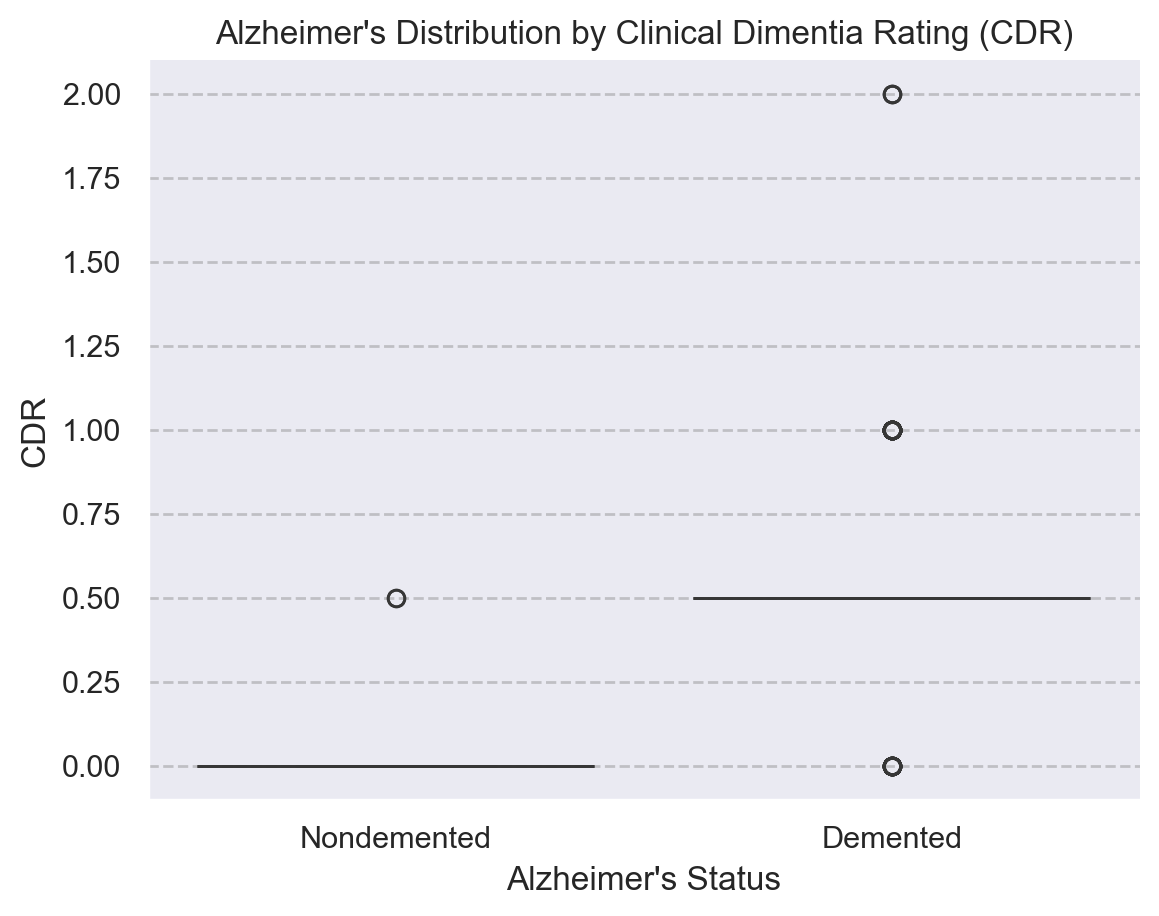

In [141]:
# Create a box-and-whisker plot of the `CDR` column for each category of the `GroupSimple` column using seaborn
# Add the title "Age Distribution by CDR" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Remove the right and top spines
# show outliers in the boxplot and use the colorblind palette
sns.boxplot(data=df, x='GroupSimple', y='CDR', palette='colorblind', hue='GroupSimple', dodge=False, zorder=3, showfliers=True)
plt.title('Alzheimer\'s Distribution by Clinical Dimentia Rating (CDR)')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('CDR')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
sns.despine()
plt.show() 

#### Normalized Whole Brain Volume

The `nWBV` column contains information about the patients' normalized whole brain volume. 

In [135]:
# Calculate summary statistics of the `nWBV` column
df['nWBV'].describe()

count    354.000000
mean       0.729879
std        0.037842
min        0.644000
25%        0.699000
50%        0.729000
75%        0.757000
max        0.837000
Name: nWBV, dtype: float64

The average nWBV of patients in the dataset is $0.73$ with a standard deviation of $0.04$. The nWBVs range from $0.644-0.837$. The median nWBV is $0.729$, the $25^{th}$ percentile nWBV is $0.699$, and the $75^{th}$ percentile nWBV is $.757$. 

In [136]:
# Calculate the interquartile range of the `nWBV` column using the stats module
stats.iqr(df['nWBV'])

np.float64(0.05800000000000005)

The interquartile range of the patient nWBVs is $0.058$. 

In [137]:
# Calculate summary statistics of the `nWBV` column grouped by each category of the `GroupSimple` column
df.groupby('GroupSimple')['nWBV'].describe()

,count,mean,std,min,25%,50%,75%,max
GroupSimple,,,,,,,,
Demented,164.0,0.71711,0.033871,0.646,0.69275,0.713,0.7395,0.806
Nondemented,190.0,0.74090,0.037705,0.644,0.71725,0.739,0.7690,0.837


For the demented patients, their mean nWBV is $0.717$ with a standard deviation of $0.034$, median nWBV is $0.713$,  $25^{th}$ percentile nWBV is $0.693$,  $75^{th}$ percentile rating is $0.740$, and nWBV range is $0.646-0.806$. For the nondemented patients, their mean nWBV is $0.741$ with a standard deviation of $0.038$, median nWBV is $0.739$,  $25^{th}$ percentile nWBV is $0.717$,  $75^{th}$ percentile nWBV is $0.769$, and rating range is $0.644-0.837$. 

In [138]:
# Use the stats module to calculate the interquartile range for each category of the `GroupSimple` column
df.groupby('GroupSimple')['nWBV'].apply(stats.iqr)

GroupSimple
Demented       0.04675
Nondemented    0.05175
Name: nWBV, dtype: float64

For the demented patients, their nWBVs' interquartile range is $0.047$. For the nondemented patients, their nWBVs' interquartile range is $0.52$.

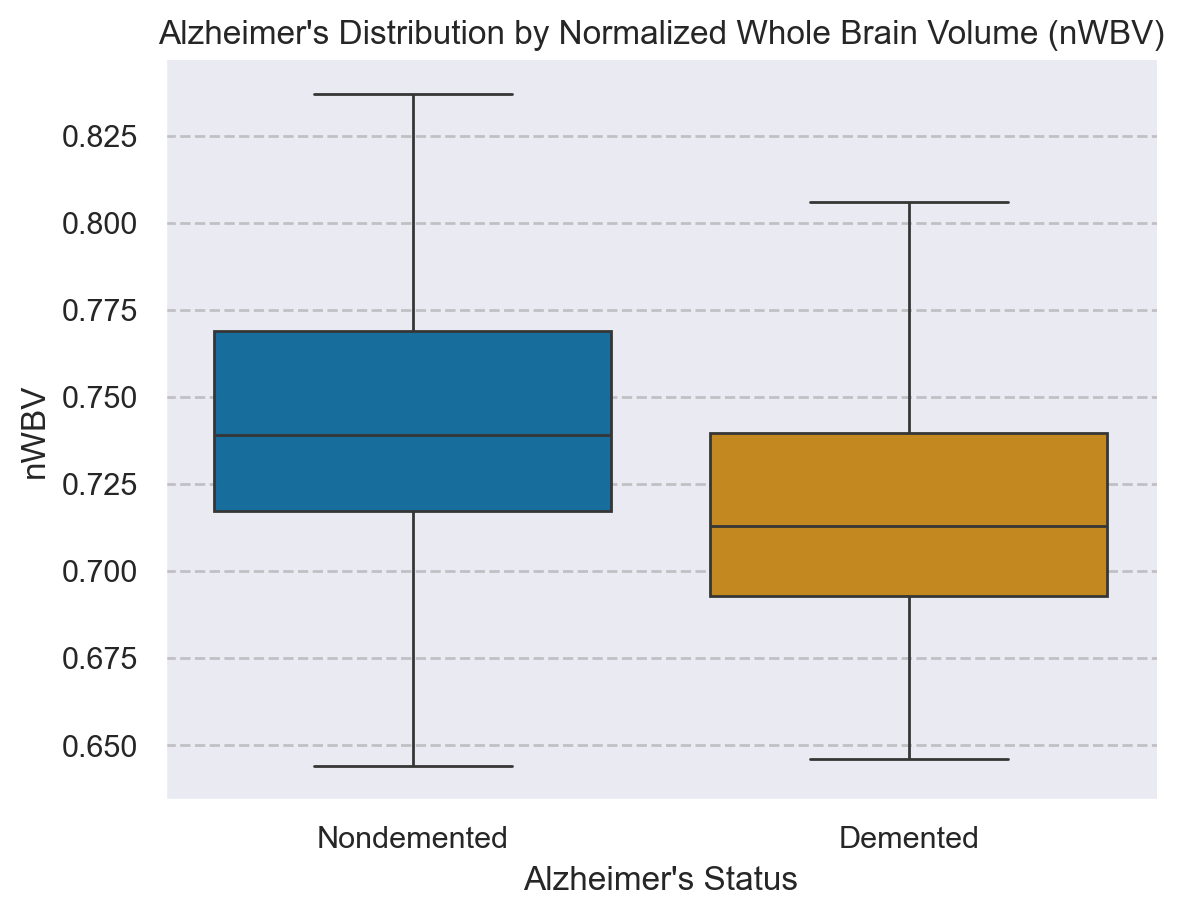

In [140]:
# Create a box-and-whisker plot of the `nWBV` column for each category of the `GroupSimple` column using seaborn
# Add the title "Age Distribution by Normalized Whole Brain Volume (nWBV)" and label the axes
# Add a horizontal grid to the plot. Make sure the grid lines are behind the bars
# Remove the right and top spines
# show outliers in the boxplot and use the colorblind palette
sns.boxplot(data=df, x='GroupSimple', y='nWBV', palette='colorblind', hue='GroupSimple', dodge=False, zorder=3, showfliers=True)
plt.title('Alzheimer\'s Distribution by Normalized Whole Brain Volume (nWBV)')
plt.xlabel('Alzheimer\'s Status')
plt.ylabel('nWBV')
plt.grid(axis='y', linestyle='--', alpha=.4, zorder=0, color='grey')
plt.gca().set_axisbelow(True)
sns.despine()
plt.show()

### Research Questions

## Discussion

Less education -> more people with Alsheimer's. 

## Conclusion

## Bibliography

<a id="link_1"></a>[$1$](#link_1): Lui F, Tsao JW. Alzheimer Disease. [Updated $2024$ Feb $12$]. In: StatPearls [Internet]. Treasure Island (FL): StatPearls Publishing; $$2026$. Available from: https://www.ncbi.nlm.nih.gov/books/NBK499922/ 
<a id="link_2"></a>[$2$](#link_2): Alzheimer's Association ($1$). $2024$ Alzheimer's disease facts and figures. Alzheimer's \& Dementia [Internet]. $2024$; $20(5)$: $3708-3821$. Available from: https://doi.org/10.1002/alz.13809
<a id="link_3"></a>[$3$](#link_3): Irwin K, Sexton C, Daniel T, Lawlor B and Naci L. Healthy Aging and Dementia: Two Roads Diverging in Midlife?. Frontiers in Aging Neuroscience [Internet]. $2018$; $10:275$. Available from: https://doi.org/10.3389/fnagi.2018.00275
<a id="link_4"></a>[$4$](#link_4): Wang AY, Hu HY, Ou YN, Wang ZT, Ma YH, Tan L, Yu JT. Socioeconomic Status and Risks of Cognitive Impairment and Dementia: A Systematic Review and Meta-Analysis of $39$ Prospective Studies. J Prev Alzheimers Dis. $2023$; $10(1):83-94$. Available from: https://doi.org/10.14283/jpad.2022.81
<a id="link_5"></a>[$5$](#link_5): Alzheimer's Association ($2$). Lower socioeconomic status linked to dementia | AAIC | Alz.org [Internet]. AAIC. $2022$. Available from: https://aaic.alz.org/releases_2022/lower-socioeconomic-dementia-risk.asp
<a id="link_6"></a>[$6$](#link_6): Cha H, Farina MP, Hayward MD. Socioeconomic status across the life course and dementia-status life expectancy among older Americans. SSM - Population Health [Internet]. 2021 Sep $1$; $15:100921$. Available from: https://doi.org/10.1016/j.ssmph.2021.100921
<a id="link_7"></a>[$7$](#link_7): Mejia-Arango S, Garcia-Cifuentes E, Samper-Ternent R, Borda MG, Cano-Gutierrez CA. Socioeconomic Disparities and Gender Inequalities in Dementia: a Community-Dwelling Population Study from a Middle-Income Country. Journal of Cross-Cultural Gerontology [Internet]. $2020$ Nov $27$; $36(1):105–18$. Available from: https://doi.org/10.1007/s10823-020-09418-4
<a id="link_8"></a>[$8$](#link_8): Deckers K, Cadar D, Van Boxtel MPJ, Verhey FRJ, Steptoe A, Köhler S. Modifiable Risk Factors Explain Socioeconomic Inequalities in Dementia Risk: Evidence from a Population-Based Prospective Cohort Study. Journal of Alzheimer S Disease [Internet]. $2019$ Aug $16$; $71(2):549–57$. Available from: https://doi.org/10.3233/jad-190541 
<a id="link_9"></a>[$9$](#link_9): Fotenos AF, Snyder AZ, Girton LE, Morris JC, Buckner RL. Normative estimates of cross-sectional and longitudinal brain volume decline in aging and AD. Neurology [Internet]. $2005$ Mar $22$; $64(6):1032–9$. Available from: https://doi.org/10.1212/01.wnl.0000154530.72969.11
<a id="link_10"></a>[$10$](#link_10): Jack CR, Petersen RC, Xu Y, O’Brien PC, Smith GE, Ivnik RJ, et al. Rates of hippocampal atrophy correlate with change in clinical status in aging and AD. Neurology [Internet]. $2000$ Aug $22$; $55(4):484–90$. Available from: https://doi.org/10.1212/wnl.55.4.484
<a id="link_11"></a>[$11$](#link_11): Petersen RC, Smith GE, Waring SC, Ivnik RJ, Tangalos EG, Kokmen E. Mild cognitive impairment. Archives of Neurology [Internet]. $1999$ Mar $1$; $56(3):303$. Available from: https://doi.org/10.1001/archneur.56.3.303
<a id="link_12"></a>[$12$](#link_12): Ward A, Arrighi HM, Michels S, Cedarbaum JM. Mild cognitive impairment: Disparity of incidence and prevalence estimates. Alzheimer S \& Dementia [Internet]. $2012$ Jan $1$; $8(1):14–21$. Available from: https://doi.org/10.1016/j.jalz.2011.01.002
<a id="link_13"></a>[$13$](#link_13): Ou YN, Zhang YB, Li YZ, Huang SY, Zhang W, Deng YT, et al. Socioeconomic status, lifestyle and risk of incident dementia: a prospective cohort study of $276730$ participants. GeroScience [Internet]. $2023$ Nov $6$; $46(2):2265–79$. Available from: https://doi.org/10.1007/s11357-023-00994-0
<a id="link_14"></a>[$14$](#link_14): Lai KY, Webster C, Kumari S, Gallacher JEJ, Sarkar C. The associations of socioeconomic status with incident dementia and Alzheimer’s disease are modified by leucocyte telomere length: a population-based cohort study. Scientific Reports [Internet]. $2023$ Apr $15$; $13(1):6163$. Available from: https://doi.org/10.1038/s41598-023-32974-x
<a id="link_15"></a>[$15$](#link_15): Adkins‐Jackson PB, George KM, Besser LM, Hyun J, Lamar M, Hill‐Jarrett TG, et al. The structural and social determinants of Alzheimer’s disease related dementias. Alzheimer S \& Dementia [Internet]. $2023$ Apr $19$; $19(7):3171–85$. Available from: https://doi.org/10.1002/alz.13027
<a id="link_16"></a>[$16$](#link_16): Barnes J, Bartlett JW, Wolk DA, Van Der Flier WM, Frost C. Disease course varies according to age and symptom length in Alzheimer’s disease. Journal of Alzheimer S Disease [Internet]. $2018$ Jun $12$; $64(2):631–42$. Available from: https://doi.org/10.3233/jad-170841
<a id="link_17"></a>[$17$](#link_17): Huff FJ, Growdon JH, Corkin S, Rosen TJ. Age at onset and rate of progression of Alzheimer’s disease. Journal of the American Geriatrics Society [Internet]. $1987$ Jan $1$; $35(1):27–30$. Available from: https://doi.org/10.1111/j.1532-5415.1987.tb01315.x
<a id="link_18"></a>[$18$](#link_18): Mungas D, Reed BR, Ellis WG, Jagust WJ. The effects of age on rate of progression of Alzheimer disease and dementia with associated cerebrovascular disease. Archives of Neurology [Internet]. $2001$ Aug $1$; $58(8):1243$. Available from: https://doi.org/10.1001/archneur.58.8.1243
<a id="link_19"></a>[$19$](#link_19): Mejia-Arango S, Garcia-Cifuentes E, Samper-Ternent R, Borda MG, Cano-Gutierrez CA. Socioeconomic Disparities and Gender Inequalities in Dementia: a Community-Dwelling Population Study from a Middle-Income Country. Journal of Cross-Cultural Gerontology [Internet]. $2020$ Nov $27$; $36(1):105–18$. Available from: https://doi.org/10.1007/s10823-020-09418-4
<a id="link_20"></a>[$20$](#link_20): Geraets AFJ, Leist AK. Sex/gender and socioeconomic differences in modifiable risk factors for dementia. Scientific Reports [Internet]. $2023$ Jan $3$; $13(1):80$. Available from: https://doi.org/10.1038/s41598-022-27368-4
<a id="link_21"></a>[$21$](#link_21): Li R, Li R, Xie J, Chen J, Liu S, Pan A, et al. Associations of socioeconomic status and healthy lifestyle with incident early-onset and late-onset dementia: a prospective cohort study. The Lancet Healthy Longevity [Internet]. $2023$ Nov $29$; $4(12):e693–702$. Available from: https://doi.org/10.1016/s2666-7568(23)00211-8
<a id="link_22"></a>[$22$](#link_22): Kalish VB, Lerner B. Mini-Mental state examination for the detection of dementia in older patients [Internet]. AAFP. $2016$; $94(11):880-881$. Available from: https://www.aafp.org/pubs/afp/issues/2016/1201/p880.html
<a id="link_23"></a>[$23$](#link_23): Monfared AAT, Byrnes MJ, White LA, Zhang Q. Alzheimer’s Disease: Epidemiology and clinical progression. Neurology and Therapy [Internet]. $2022$ Mar $14$; $11(2):553–69$. Available from: https://doi.org/10.1007/s40120-022-00338-8
<a id="link_24"></a>[$24$](#link_24): Marcus DS, Wang TH, Parker J, Csernansky JG, Morris JC, Buckner RL. Open Access Series of Imaging Studies (OASIS): cross-sectional MRI data in young, middle aged, nondemented, and demented older adults. Journal of Cognitive Neuroscience [Internet]. $2007$ Aug $22$; $19(9):1498–507$. Available from: https://doi.org/10.1162/jocn.2007.19.9.1498
<a id="link_25"></a>[$25$](#link_25): Buckner RL, Head D, Parker J, Fotenos AF, Marcus D, Morris JC, et al. A unified approach for morphometric and functional data analysis in young, old, and demented adults using automated atlas-based head size normalization: reliability and validation against manual measurement of total intracranial volume. NeuroImage [Internet]. $2004$ Sep $10$; $23(2):724–38$. Available from: https://doi.org/10.1016/j.neuroimage.2004.06.018
<a id="link_26"></a>[$26$](#link_26): Perneczky R, Wagenpfeil S, Komossa K, Grimmer T, Diehl J, Kurz A. Mapping scores onto stages: Mini-Mental state examination and Clinical dementia rating. American Journal of Geriatric Psychiatry [Internet]. $2006$ Feb $1$; $14(2):139–44$. Available from: https://doi.org/10.1097/01.jgp.0000192478.82189.a8
<a id="link_27"></a>[$27$](#link_27): Savva GM, Wharton SB, Ince PG, Forster G, Matthews FE, Brayne C. Age, neuropathology, and dementia. New England Journal of Medicine [Internet]. $2009$ May $27$; $360(22):2302–9$. Available from: https://doi.org/10.1056/nejmoa0806142